In [1]:
import os
# Set environment variable to avoid KMP duplicate library error
# This is a workaround for some systems where the KMP (Intel's OpenMP) library 
# might be loaded multiple times, causing a runtime error.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from swotted import swottedModule, swottedTrainer
from swotted.utils import Subset, success_rate
from swotted.loss_metrics import *

from omegaconf import OmegaConf
# from tests.gen_data import gen_synthetic_data
from torch.utils.data import DataLoader

import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
import numpy as np

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

import pyreadstat
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
import numpy as np
import os

import datetime
from datetime import timedelta

from sklearn.preprocessing import LabelEncoder
from scipy.spatial.distance import pdist
from sklearn.preprocessing import StandardScaler

# Second run using more complex tensor

We present here a simple example to show the basic functionalities. It uses a random input tensor, more complex examples can be explored in the other [notebook](SWoTTeD_module_example.ipynb).

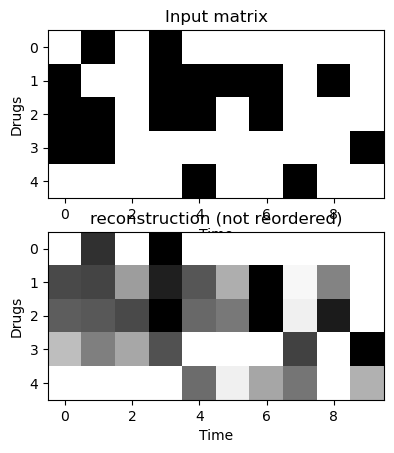

In [9]:
# make decomposition with the train model: it projects the X on the phenotypes of the model
# note that projection can be applied on new data. We use data from the training set for the sake
# of simplicity
id = 20
W = swotted(X[id, :, :].unsqueeze(0))
# Apply reconstruction
Y = swotted.model.reconstruct(W,swotted.Ph)

# Patient decomposition
plt.subplot(211)
plt.imshow(X[id].detach().numpy(), vmin=0, vmax=1, cmap="binary",interpolation='none')
plt.ylabel("Drugs")
plt.xlabel("Time")
plt.title("Input matrix")
plt.subplot(212)
plt.imshow(Y[0].detach().numpy(), vmin=0, vmax=1, cmap="binary",interpolation='none')
plt.ylabel("Drugs")
plt.xlabel("Time")
plt.title("Pathway")
plt.title("reconstruction (not reordered)")
plt.show()

In [10]:
Ph.shape

(4, 5, 3)

*Mapping of X into the Phenotype Space*

The mapping of the input tensor `X` into the phenotype space is performed using the trained SWoTTeD model. This process involves projecting the input data onto the discovered phenotypes, which allows us to represent each patient's data in terms of the identified phenotypes.

The steps involved in this mapping are as follows:

1. **Projection**: The input tensor `X` is projected onto the phenotype space using the trained SWoTTeD model. This projection is done by passing the input tensor through the model, which results in a new tensor `W`. The tensor `W` represents the weights or contributions of each phenotype for each patient over time.

2. **Reconstruction**: The projected tensor `W` can be used to reconstruct the input tensor `X` using the discovered phenotypes. This reconstruction helps in understanding how well the phenotypes capture the underlying patterns in the input data.

The following code snippet demonstrates the projection of the input tensor `X` onto the phenotype space:


In [11]:
# Project the patients onto the phenotype space
W_all = swotted(X)
W_all.shape

torch.Size([200, 4, 8])

*Reshape the Tensor for Clustering*

In the next step, we need to reshape the tensor `W_all` to prepare it for clustering. The tensor `W_all` has the shape `(K, rank, T)`, where `K` is the number of patients, `rank` is the number of phenotypes, and `T` is the length of the time window.

To perform clustering, we need to convert this 3D tensor into a 2D array where each row represents a patient and each column represents a feature. We achieve this by reshaping `W_all` to have the shape `(K, rank * T)`. This way, each patient's data is flattened into a single row, making it suitable for clustering algorithms like KMeans.

In [12]:
# Reshape W_all for clustering
W_all_reshaped = W_all.view(K, -1).detach().numpy()
W_all_reshaped.shape

(200, 32)

In [13]:
from sklearn.cluster import KMeans

# Perform KMeans clustering
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(W_all_reshaped)

# Get the cluster labels
labels = kmeans.labels_

# Print the cluster labels
print(labels)

c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 217, in _count_physical_cores
    raise ValueError(
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memor

[0 0 0 0 0 1 0 0 0 0 0 0 0 2 0 0 0 2 2 2 0 1 1 0 0 2 1 0 1 2 1 0 0 1 1 0 0
 1 0 2 1 1 0 2 0 0 0 1 2 2 0 2 0 0 2 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 2
 0 2 1 1 2 1 0 2 0 0 1 2 0 2 0 1 0 2 2 2 0 0 1 1 2 0 0 0 2 2 2 2 0 2 0 0 2
 2 1 0 1 1 0 0 0 0 1 0 0 1 1 0 1 0 0 0 0 1 1 0 2 0 1 2 0 0 1 0 0 1 0 1 0 2
 2 1 0 0 0 0 1 2 2 1 2 0 2 2 1 2 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0
 0 0 0 1 2 0 0 0 0 1 0 0 0 1 0]


### SWOTTED : first run

In [2]:
folder_path = r'C:\Users\nicolas.grevet\Documents\SESSTIM\QuanTIM\Survie\Python_Scripts\TrajectoryClusteringAnalysis\data'
file_with_multi = 'multidimensional_data.xlsx'
df = pd.read_excel(os.path.join(folder_path, file_with_multi))

In [ ]:
# df['ID_PATIENT'] = pd.factorize(df['ID_PATIENT'])[0] + 1  # Ensure IDs are positive integers
# # rename Lib_traitement to EVENT
# df.rename(columns={'Lib_traitement': 'EVENT'}, inplace=True)
# # rename ID_PATIENT to PATIENT_ID
# df.rename(columns={'ID_PATIENT': 'PATIENT_ID'}, inplace=True)
# # Convert EVENT to categorical type
# df['EVENT'] = df['EVENT'].astype('category')
# # rename Months_Since_First_Events to TIME
# df.rename(columns={'Months_Since_First_Events': 'TIME'}, inplace=True)
# df
# df.to_excel(os.path.join(folder_path, 'multidimensional_data_processed.xlsx'), index=False)
df.to_csv(os.path.join(folder_path, 'multidimensional_data.csv'), index=False)

In [19]:
label_encoder = LabelEncoder()
timed_event_structure = df.copy()

timed_event_structure['Encoded_Libellé'] = label_encoder.fit_transform(timed_event_structure['Lib_traitement'])
timed_event_structure.drop(columns=['Lib_traitement'], inplace=True)
timed_event_structure.columns = ['ID_PATIENT', 'Time', 'Event']
timed_event_structure

,ID_PATIENT,Time,Event
0,1101100224,0,2
1,1101100224,1,0
2,1101100224,1,0
3,1101100224,2,0
4,1101100224,3,0
...,...,...,...
20430,2395100171,2,0
20431,2395100171,2,0
20432,2395100171,3,0
20433,2395100171,3,0


In [22]:
# Get the set of all unique Care_Event values
unique_care_events = timed_event_structure['Event'].unique()
all_care_events = set(unique_care_events)

# Find patients who have all occurrences of Care_Event
patients_with_all_events = timed_event_structure.groupby('ID_PATIENT').filter(
    lambda group: set(group['Event']) == all_care_events
)['ID_PATIENT'].unique()

print(f"Patients with all occurrences of Event: {len(patients_with_all_events)}")
print(patients_with_all_events)

Patients with all occurrences of Event: 50
[1102101064 1106106824 1113101209 1113108284 1113108287 1129101216
 1131110060 1133106135 1133106870 1133107102 1135101974 1135109009
 1142200210 1142207628 1144105829 1153109219 1159701345 1162406498
 1167300433 1169110727 1175107539 1178105339 1178109456 1179108662
 1180107591 1192100466 1192102519 1192104720 1194100935 1204500058
 1362100938 1369101025 1378100639 2118101728 2122104008 2125101859
 2126100862 2133104385 2135103999 2141102197 2150101469 2159501945
 2159901902 2164100548 2167302100 2183103056 2192100056 2366100304
 2371100161 2394100764]


#### SWoTTeD_module_test

In [ ]:
K = 100  #: number of patients
N = 10  #: number of medical events
T = 6  #: length of time's stay
R = 4  #: number of phenotypes
Tw = 3  #: length of time's window


In [793]:
# Generating synthetic data
W_, Ph_, X, params = gen_synthetic_data(
    K, N, T, R, Tw, sliding_window=True, noise=False, truncate=True
)


In [794]:
X

[tensor([[0., 0., 0., 1., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 1., 0., 0., 1.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.]]),
 tensor([[0., 0., 1., 0., 0., 1.],
         [1., 0., 0., 1., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 1., 0., 0., 1.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [1., 0., 0., 1., 0., 0.],
         [0., 0., 0., 0., 0., 0.]]),
 tensor([[0., 0., 0., 1., 0., 0.],
         [1., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 1., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [1., 0.

In [795]:
params = {}
params["model"] = {}
params["model"]["non_succession"] = 0.5
params["model"]["sparsity"] = 0.5
params["model"]["rank"] = R
params["model"]["twl"] = Tw
params["model"]["N"] = N
params["model"]["metric"] = "Bernoulli"
params["training"] = {}
params["training"]["batch_size"] = 50
params["training"]["nepochs"] = 500
params["training"]["lr"] = 1e-3
params["predict"] = {}
params["predict"]["nepochs"] = 100
params["predict"]["lr"] = 1e-2

config = OmegaConf.create(params)

In [796]:
# define the model
swotted = swottedModule(config)

train_loader = DataLoader(
    Subset(X, np.arange(len(X))),
    batch_size=params["training"]["batch_size"],
    shuffle=False,
    collate_fn=lambda x: x,
)

# train the model (hint: here are some helpful Trainer arguments for rapid idea iteration)
trainer = swottedTrainer(
    fast_dev_run=False, max_epochs=params["training"]["nepochs"]
)
trainer.fit(model=swotted, train_dataloaders=train_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | model        | SlidingWindow | 0      | train
  | other params | n/a           | 120    | n/a  
-------------------------------------------------------
120       Trainable params
0         Non-trainable params
120       Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the va

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=500` reached.


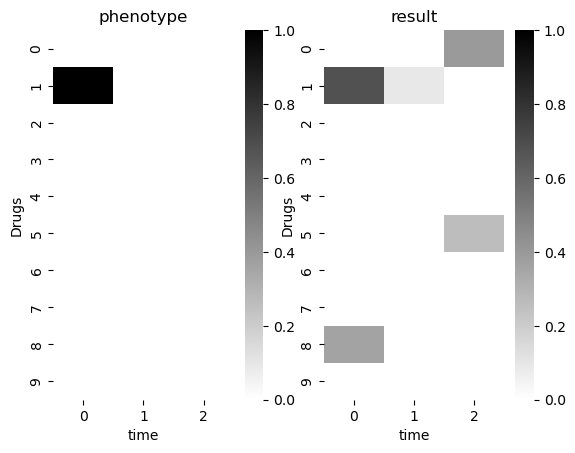

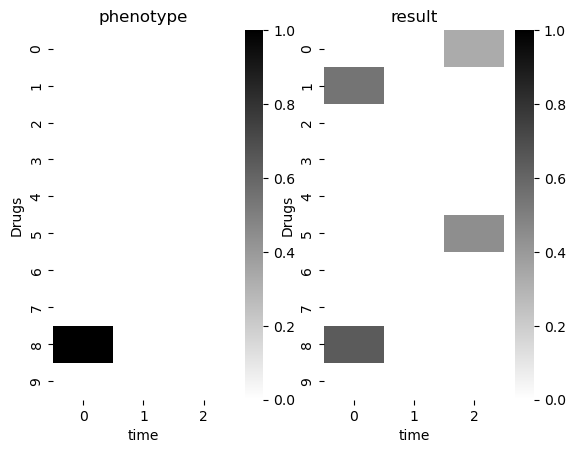

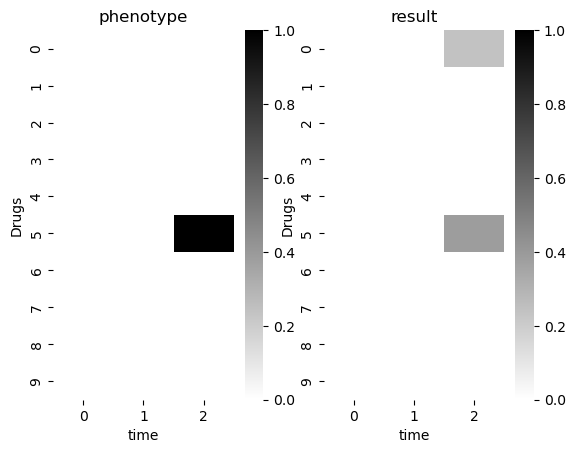

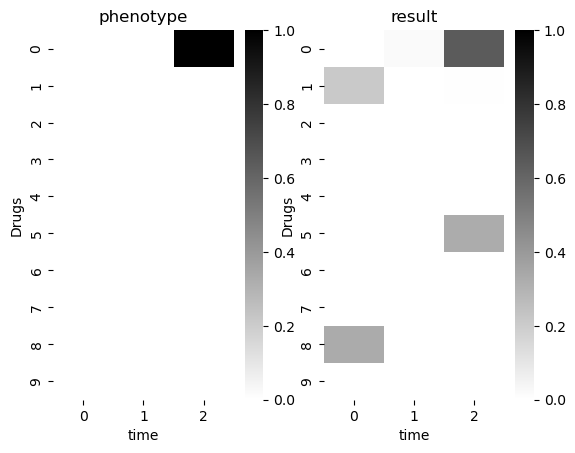

In [797]:
# visualize the phenotype
reordered_pheno, reordered_pathways = swotted.reorderPhenotypes(Ph_, tw=Tw)
for i in range(R):
    plt.subplot(121)
    sns.heatmap(Ph_[i], vmin=0, vmax=1, cmap="binary")
    plt.ylabel("Drugs")
    plt.xlabel("time")
    plt.title("phenotype")
    plt.subplot(122)
    sns.heatmap(reordered_pheno[i].detach().numpy(), vmin=0, vmax=1, cmap="binary")
    plt.ylabel("Drugs")
    plt.xlabel("time")
    plt.title("result")
    plt.show()


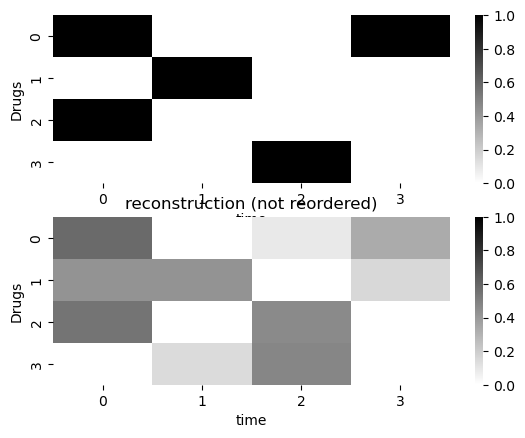

In [798]:
# make decomposition with the train model: it projects the X on the phenotypes of the model
# note that projection can be applied on new data. We use data from the training set for the sake
# of the simplicity
id = 15
W = swotted(X[id : id + 1])
_, W = swotted.reorderPhenotypes(Ph_, W)

# Visual comparison of the care pathways
plt.subplot(211)
sns.heatmap(W_[id], vmin=0, vmax=1, cmap="binary")
plt.ylabel("Drugs")
plt.xlabel("time")
plt.subplot(212)
sns.heatmap(W[0].detach().numpy(), vmin=0, vmax=1, cmap="binary")
plt.ylabel("Drugs")
plt.xlabel("time")
plt.title("reconstruction (not reordered)")
plt.show()


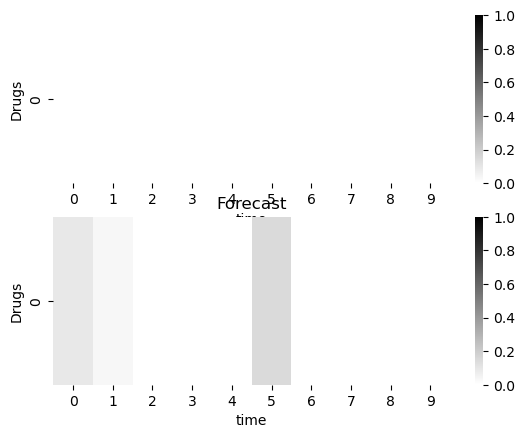

In [799]:

# we can also forecast the end of the :
id = 15
pred = swotted.forecast([X[id][:, :-1]])

# Visual comparison of the care pathways
plt.subplot(211)
sns.heatmap(X[id][:, -1].unsqueeze(0), vmin=0, vmax=1, cmap="binary")
plt.ylabel("Drugs")
plt.xlabel("time")
plt.subplot(212)
sns.heatmap(pred[0].unsqueeze(0), vmin=0, vmax=1, cmap="binary")
plt.ylabel("Drugs")
plt.xlabel("time")
plt.title("Forecast")
plt.show()

In [759]:
irregular_tensor = [
    [1, 2, 3],
    [4, 5],
    [6, 7, 8, 9]
]

irregular_tensor_array = np.array(irregular_tensor, dtype=object)
irregular_tensor_array.shape[0]

3

In [783]:
X_test_irregular = [torch.tensor(irregular_tensor_array[i]) for i in range(irregular_tensor_array.shape[0])]
X_test_irregular

[tensor([1, 2, 3]), tensor([4, 5]), tensor([6, 7, 8, 9])]

In [779]:
# X_test_irregular = []
# for p in range(K):
#     # create a tensor of windows
#     dec = torch.tensordot(Uk[p], Vk, dims=([0], [0]))

#     # now ... windows have to be summed
#     Yp = torch.zeros((N, T))
#     for i in range(T - Tw + 1):
#         Yp[:, i : (i + Tw)] += dec[i]

#     X_test_irregular.append(Yp)

X_test_irregular = torch.stack(X_test_irregular)

RuntimeError: stack expects each tensor to be equal size, but got [3] at entry 0 and [2] at entry 1

In [777]:
X_test_irregular = torch.stack(X_test_irregular)

TypeError: expected Tensor as element 0 in argument 0, but got list

In [769]:
from swotted.utils import Subset

Subset(X, np.arange(len(X)))

In [762]:
X_test_irregular = [
    torch.cat(tuple([irregular_tensor_array[i][j] for j in range(irregular_tensor_array.shape[1])]), axis=1)
    for i in range(irregular_tensor_array.shape[0])
]

TypeError: expected Tensor as element 0 in argument 0, but got int

#### FastSWOTTED model

In [217]:
unique_patients = timed_event_structure['ID_PATIENT'].unique()
unique_care_events = timed_event_structure['Care_Event'].unique()
unique_time_points = timed_event_structure['Time'].unique()

patient_to_index = {patient: idx for idx, patient in enumerate(unique_patients)}

K = len(unique_patients)  #: number of patients
N = len(unique_care_events)  #: number of medical events
T = len(unique_time_points)  #: length of time's stay

tensor = np.zeros((K, N, T), dtype=int)
for _, row in timed_event_structure.iterrows():
    patient_idx = patient_to_index[row['ID_PATIENT']]
    care_event_idx = np.where(unique_care_events == row['Care_Event'])[0][0]
    time_idx = np.where(unique_time_points == row['Time'])[0][0]
    tensor[patient_idx, care_event_idx, time_idx] = 1

X = torch.tensor(tensor, dtype=torch.float32)

# The resulting tensor is a 3D binary tensor
X.shape  # (number of patients, number of care events, number of time points)

torch.Size([1029, 4, 25])

In [218]:
params = {}
params["model"] = {}
params["model"]["non_succession"] = 0.5
params["model"]["sparsity"] = 0.5
params["model"]["rank"] = 3  #: number of phenotypes to discover
params["model"]["twl"] = 3  #: length of time's window
params["model"]["N"] = N
params["model"]["metric"] = "Bernoulli"
params["training"] = {}
params["training"]["batch_size"] = 40
params["training"]["nepochs"] = 100
params["training"]["lr"] = 1e-2
params["predict"] = {}
params["predict"]["nepochs"] = 100
params["predict"]["lr"] = 1e-2

config = OmegaConf.create(params)

# define the model
fastswotted = fastSWoTTeDModule(config)

train_loader = DataLoader(
    fastSWoTTeDDataset(X),
    batch_size=params["training"]["batch_size"],
    shuffle=False,
    collate_fn=lambda x: x,
)

# train the model
trainer = fastSWoTTeDTrainer(
    max_epochs=params["training"]["nepochs"]
)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [921]:
trainer.fit(model=fastswotted, train_dataloaders=train_loader)

c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | model        | SlidingWindowConv | 0      | train
  | other params | n/a               | 48     | n/a  
-----------------------------------------------------------
48        Trainable params
0         Non-trainable params
48        Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve perfo

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


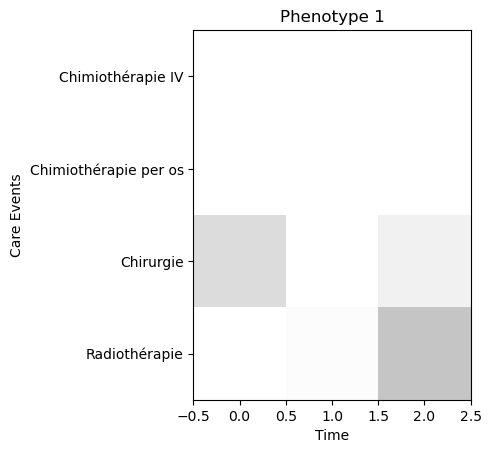

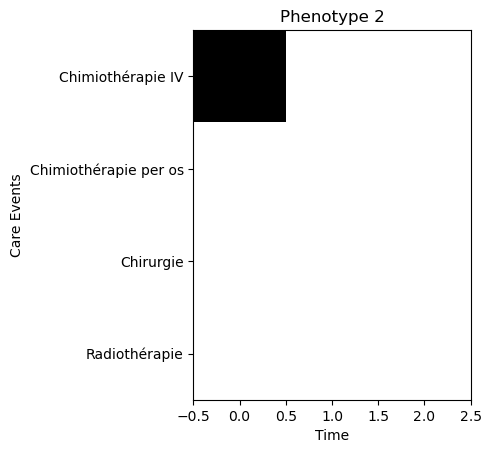

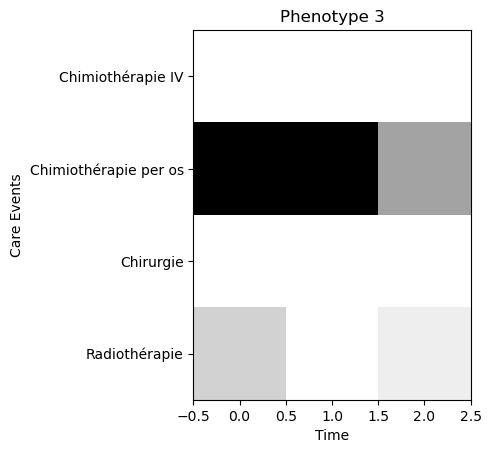

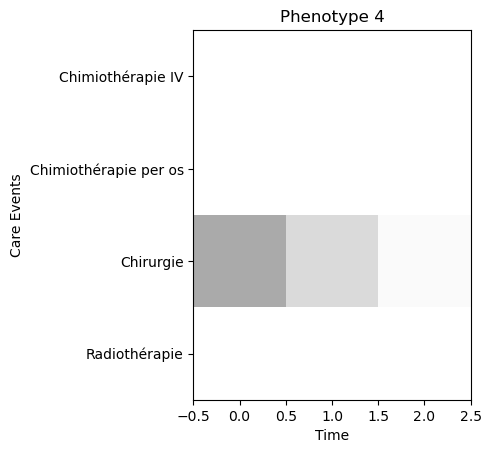

In [928]:
# visualize the phenotypes
Ph = fastswotted.Ph.flip(2).detach().numpy()

for i in range(params["model"]["rank"]):
    plt.imshow(Ph[i], vmin=0, vmax=1, cmap="binary", interpolation='none')
    plt.ylabel("Care Events")
    plt.xlabel("Time")
    plt.title("Phenotype " + str(i+1))
    plt.yticks(range(Ph[i].shape[0]), label_encoder.inverse_transform(range(Ph[i].shape[0])))
    plt.show()

In [923]:
patient_index = np.where(unique_patients == '1102101064')[0][0]
id = patient_index

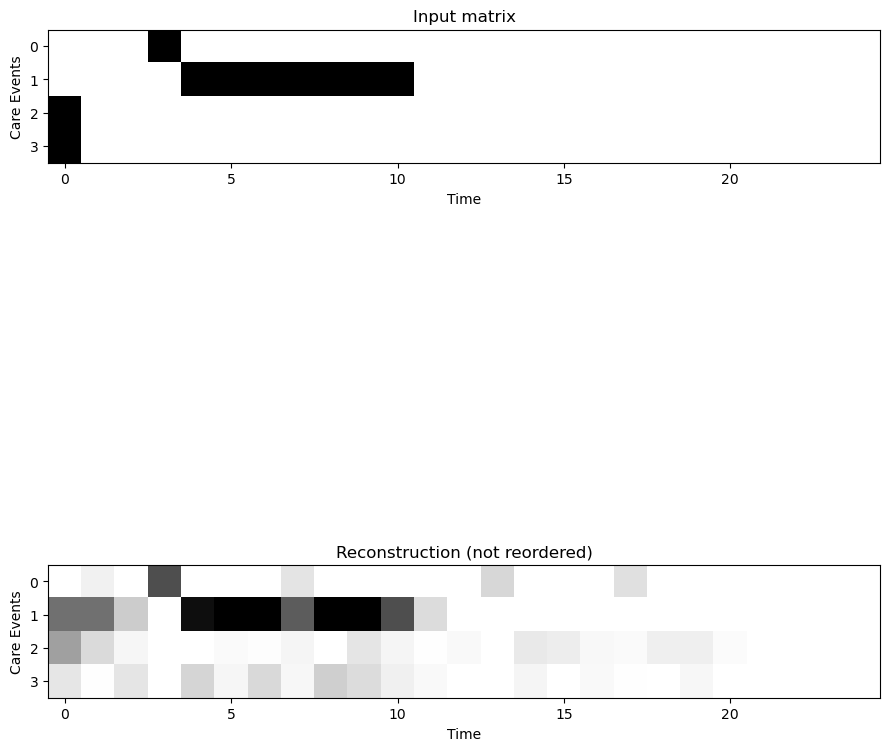

In [931]:
# make decomposition with the train model: it projects the X on the phenotypes of the model
# note that projection can be applied on new data. We use data from the training set for the sake
# of simplicity
W = fastswotted(X[id, :, :].unsqueeze(0))
# Apply reconstruction
Y = fastswotted.model.reconstruct(W, fastswotted.Ph)

# Patient decomposition
plt.figure(figsize=(9, 14))
plt.subplot(211)
plt.imshow(X[id].detach().numpy(), vmin=0, vmax=1, cmap="binary", interpolation='none')
plt.ylabel("Care Events")
plt.xlabel("Time")
plt.title("Input matrix")
plt.subplot(212)
plt.imshow(Y[0].detach().numpy(), vmin=0, vmax=1, cmap="binary", interpolation='none')
plt.ylabel("Care Events")
plt.xlabel("Time")
plt.title("Reconstruction (not reordered)")
plt.tight_layout()
plt.show()

In [932]:
Ph.shape

(4, 4, 3)

In [933]:
# Project the patients onto the phenotype space
W_all = fastswotted(X)
W_all.shape

torch.Size([908, 4, 23])

In [354]:
# Reshape W_all for clustering
K = X.shape[0]  #: number of patients
W_all_reshaped = W_all.view(K, -1).detach().numpy()
W_all_reshaped.shape

(1640, 637)

In [355]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(W_all_reshaped)

labels = kmeans.labels_
print(labels)

c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


[0 1 0 ... 1 2 2]


#### SWOTTED model

In [ ]:
def plot_fit_over_epochs(X, X_reconstructed_list):
    """
    Compute and plot the FIT metric over training epochs for tensor decomposition.

    Parameters
    ----------
    X : torch.Tensor or np.ndarray
        Original data tensor.
    X_reconstructed_list : list of torch.Tensor or np.ndarray
        List of reconstructed tensors at each epoch.
    """

    # Convert to numpy if needed
    X_np = X.detach().cpu().numpy() if hasattr(X, "detach") else np.array(X)
    fit_metrics = []
    for X_rec in X_reconstructed_list:
        X_rec_np = X_rec.detach().cpu().numpy() if hasattr(X_rec, "detach") else np.array(X_rec)
        num = np.linalg.norm(X_np - X_rec_np)
        denom = np.linalg.norm(X_np)
        fit = 1 - (num / denom)
        fit_metrics.append(fit)

    epochs = range(1, len(fit_metrics) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, fit_metrics, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('FIT')
    plt.title('FIT over Epochs')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
X_reconstructed_list = []
for i in range(W_all.shape[0]): 
    X_reconstructed = swotted.model.reconstruct(W_all[i], swotted.Ph)
    X_reconstructed_list.append(X_reconstructed)

     
plot_fit_over_epochs(X, swotted.model.X_reconstructed_list)

In [23]:
unique_patients = timed_event_structure['ID_PATIENT'].unique()
unique_care_events = timed_event_structure['Event'].unique()
unique_time_points = timed_event_structure['Time'].unique()

patient_to_index = {patient: idx for idx, patient in enumerate(unique_patients)}

K = len(unique_patients)  #: number of patients
N = len(unique_care_events)  #: number of medical events
T = len(unique_time_points)  #: length of time's stay

tensor = np.zeros((K, N, T), dtype=int)
for _, row in timed_event_structure.iterrows():
    patient_idx = patient_to_index[row['ID_PATIENT']]
    care_event_idx = np.where(unique_care_events == row['Event'])[0][0]
    time_idx = np.where(unique_time_points == row['Time'])[0][0]
    tensor[patient_idx, care_event_idx, time_idx] = 1

X = torch.tensor(tensor, dtype=torch.float32)

X.shape  # (number of patients, number of care events, number of time points)

torch.Size([1336, 4, 24])

In [24]:
R = 3  #: number of phenotypes
Tw = 3  #: length of time's window

In [25]:
params = {}
params['model']={}
params['model']['non_succession']=0.5
params['model']['sparsity']=0.5
params['model']['rank']=R
params['model']['twl']=Tw
params['model']['N']=N
params['model']['metric']="Bernoulli"

#some additional parameters of the trainer
params['training']={}
params['training']['lr']=1e-2

#some additional parameters for the projection (decomposition on new sequences)
params['predict']={}
params['predict']['nepochs']=100
params['predict']['lr']=1e-2

config=OmegaConf.create(params)

In [109]:
# define the model
swotted = swottedModule(config)
# train the model
trainer = swottedTrainer(max_epochs=200)

train_loader = DataLoader(
    Subset(X, np.arange(len(X))),
    batch_size=15,
    # num_workers=31,
    shuffle=False,
    collate_fn=lambda x: x,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [ ]:
# Standard training loop using PyTorch Lightning Trainer
trainer.fit(model=swotted, train_dataloaders=train_loader)




  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | model        | SlidingWindow | 0      | train
  | other params | n/a           | 36     | n/a  
-------------------------------------------------------
36        Trainable params
0         Non-trainable params
36        Total params
0.000     Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
c:\Users\nicolas.grevet\AppData\Local\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


In [ ]:
print(success_rate(X, )

<function success_rate at 0x00000224A1C08CC0>


In [639]:
# # visualize the phenotypes
# Ph = swotted.Ph.flip(2).detach().numpy()

# # visualize the phenotype
# reordered_pheno, reordered_pathways = swotted.reorderPhenotypes(torch.tensor(Ph), tw=4)

# for i in range(params["model"]["rank"]):
#     plt.subplot(211)
#     plt.imshow(Ph[i], vmin=0, vmax=1, cmap="binary", interpolation='none')
#     plt.ylabel("Care Events")
#     plt.xlabel("Time")
#     plt.title("Phenotype " + str(i+1))
#     plt.yticks(range(Ph[i].shape[0]), label_encoder.inverse_transform(range(Ph[i].shape[0])))
#     plt.show()
#     plt.subplot(212)
#     plt.imshow(reordered_pheno[i].detach().numpy(), vmin=0, vmax=1, cmap="binary", interpolation="nearest")
#     plt.ylabel("Care Events")
#     plt.xlabel("Time")
#     plt.title("result")
#     plt.yticks(range(Ph[i].shape[0]), label_encoder.inverse_transform(range(Ph[i].shape[0])))
#     plt.show()

In [29]:
swotted.Ph.shape

torch.Size([3, 4, 3])

In [33]:
patient_index = np.where(unique_patients == 1102101064)[0][0]
id = patient_index
patient_data = X[patient_index]
patient_data

tensor([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 1., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0.]])

In [34]:
id = patient_index

# W = swotted(X[id:id+1])
W = swotted(X[id, :, :].unsqueeze(0))
Ph = swotted.Ph.flip(2).detach().numpy()

#reorder the row of the pathway
rPh, rW = swotted.reorderPhenotypes(gen_pheno=torch.tensor(Ph), Wk=W, tw=Tw)
X_pred = swotted.model.reconstruct(rW[0], rPh)

rW[0].shape

torch.Size([3, 22])

In [35]:
W_all = swotted(X)

In [36]:
# Compute the reconstructed X for the entire dataset
# W_all = swotted(X)
X_reconstructed = []
for p in range(K):
    X_reconstructed.append(swotted.model.reconstruct(W_all[p], swotted.Ph))
X_reconstructed = torch.stack(X_reconstructed)

# Compute the FIT metric for the entire dataset
fit_metric = 1 - (torch.norm(X - X_reconstructed) / torch.norm(X))
print(f"FIT metric for the entire dataset: {fit_metric.item():.4f}")

FIT metric for the entire dataset: -3.3902


In [278]:
# import tensorly as tl

# fit = 1 - (tl.norm(X.detach().numpy() - X_reconstructed.detach().numpy()) / tl.norm(X.detach().numpy()))
# fit_percentage = fit * 100

# print(f"Fit metric: {fit_percentage:.2f}%")

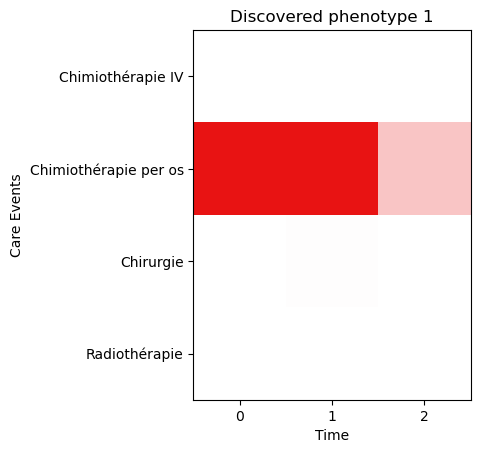

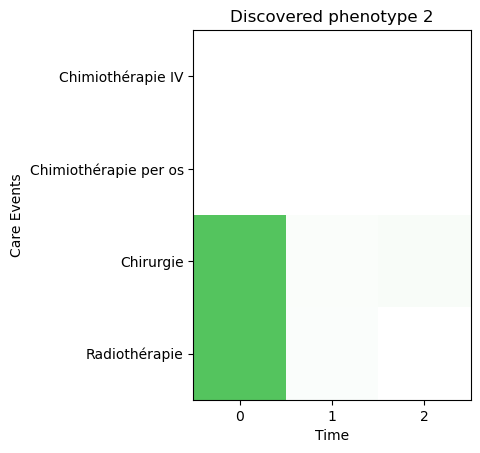

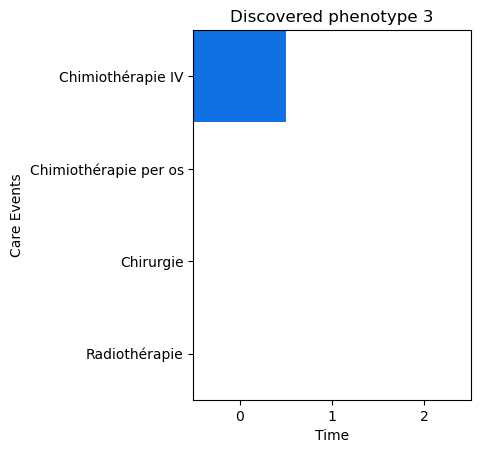

In [37]:
import matplotlib.colors as mcolors

color_code = ['#E81313', '#54C45E', '#1071E5']

for i in range(params["model"]["rank"]):
    # Create a colormap based on the base color
    base_color = color_code[i % len(color_code)]
    cmap = mcolors.LinearSegmentedColormap.from_list(f"custom_cmap_{i}", ["white", base_color])

    # Plot the phenotype matrix with the custom colormap
    plt.imshow(rPh[i].detach().numpy(), vmin=0, vmax=1, cmap=cmap, interpolation='none')
    plt.ylabel("Care Events")
    plt.xticks(range(rPh[i].shape[1]), range(rPh[i].shape[1]))
    plt.xlabel("Time")
    plt.title(f"Discovered phenotype {i + 1}")
    plt.yticks(range(rPh[i].shape[0]), label_encoder.inverse_transform(range(rPh[i].shape[0])))
    # plt.colorbar(label="Intensity")
    plt.show()

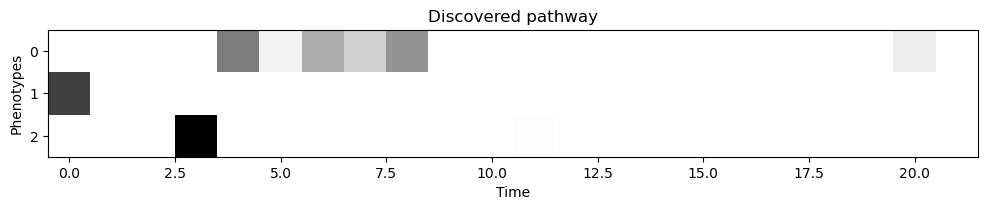

In [38]:
plt.figure(figsize=(12, 8)) 
plt.imshow(rW[0].detach().numpy(), vmin=0, vmax=1, cmap="binary", interpolation="nearest")
plt.ylabel("Phenotypes")
plt.yticks(range(rW[0].shape[0]), )
plt.xlabel("Time")
plt.title("Discovered pathway")
plt.show()


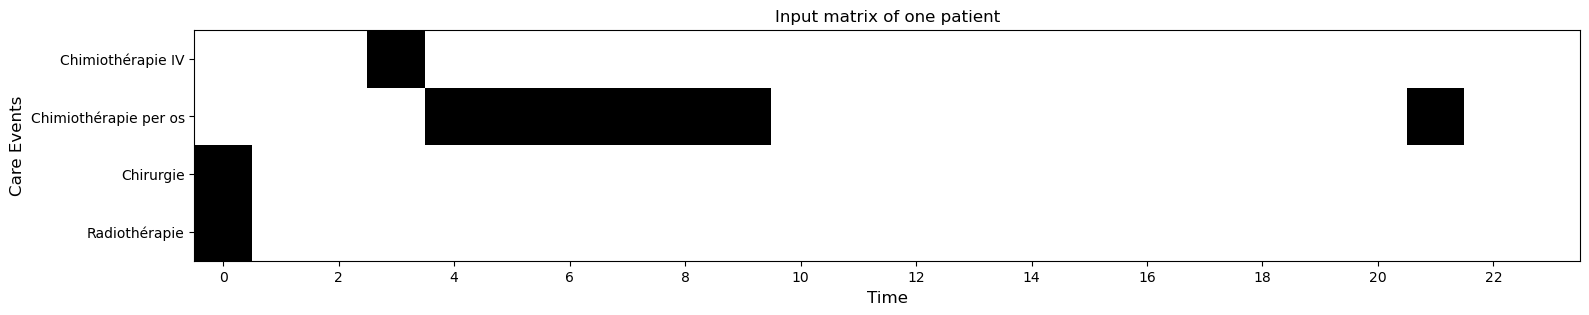

In [39]:
T = X[id].shape[1]

fig, axs = plt.subplots(figsize=(16, 12))
axs.imshow(X[id], vmin=0, vmax=1, cmap="binary", interpolation='none')
axs.set_title("Input matrix of one patient", fontsize=12) 
axs.set_xlabel("Time", fontsize=12)
axs.set_ylabel("Care Events", fontsize=12)
axs.set_xticks(np.arange(0, T, 2)) 
axs.set_yticks(range(X[id].shape[0]))
axs.set_yticklabels(label_encoder.inverse_transform(range(X[id].shape[0])), fontsize=10)
plt.tight_layout()
plt.show()

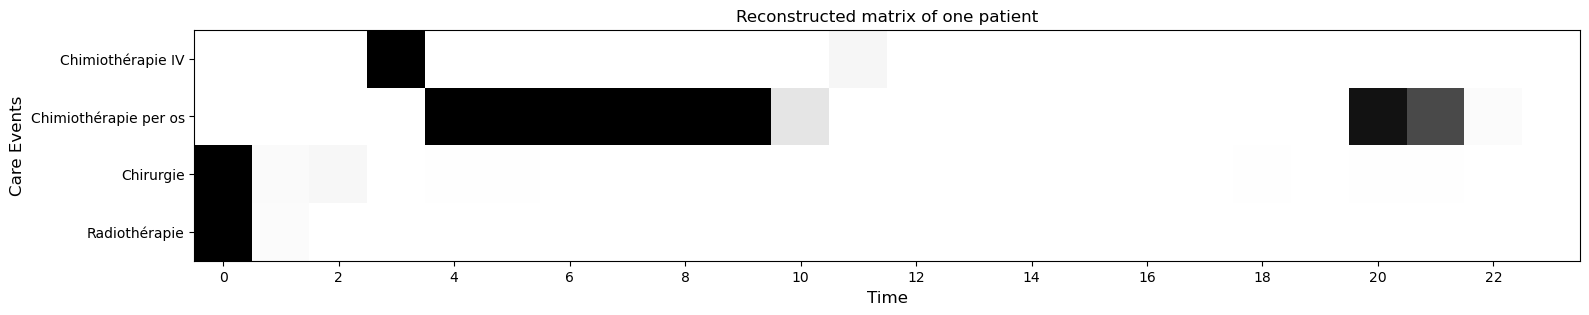

In [40]:
fig, axs = plt.subplots(figsize=(16, 12))
axs.imshow(X_pred.detach().numpy(), vmin=0, vmax=1, cmap="binary", interpolation='none')
axs.set_title("Reconstructed matrix of one patient", fontsize=12) 
axs.set_xlabel("Time", fontsize=12)
axs.set_ylabel("Care Events", fontsize=12)
axs.set_xticks(np.arange(0, T, 2)) 
axs.set_yticks(range(X[id].shape[0]))
axs.set_yticklabels(label_encoder.inverse_transform(range(X[id].shape[0])), fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
FITx = 

FITx

-1.4590691895463501

Création d’un vecteur de caractéristiques par patient Une fois le modèle entraîné, chaque patient est associé à une matrice 𝑊 qui constitue son « chemin », c’est-à-dire la séquence (ou l’occurrence) des phénotypes durant son séjour. Pour passer au clustering, vous pouvez :

Résumer l’activité de chaque phénotype : Calculer, par exemple, le nombre total d’occurrences ou la durée cumulée de chaque phénotype dans le parcours du patient. Cela permet de transformer la matrice 𝑊 en un vecteur 𝑣∈𝑅
où chaque composante représente l’importance ou la fréquence du phénotype 𝑟 pour le patient.

Extraire des indicateurs temporels : En plus de la fréquence, vous pouvez intégrer des informations sur le début, la fin ou les intervalles entre les occurrences pour capturer la dynamique temporelle.

Normalisation et réduction de dimension (optionnel) Avant d’appliquer un algorithme de clustering, il peut être pertinent de normaliser ces vecteurs ou d’utiliser des techniques de réduction de dimension (comme PCA ou t-SNE) pour visualiser les relations entre les patients dans un espace plus compact et interprétable.

In [44]:
W_all = torch.stack(W_all)
W_all.shape

torch.Size([1336, 3, 22])

In [293]:
# # Reshape W_all for clustering
# W_all_reshaped = X_reconstructed.view(K, -1).detach().numpy()
# W_all_reshaped.shape

In [45]:
# Calculate the total occurrences or cumulative duration of each phenotype for each patient
# Summing along the time axis (axis=2)
phenotype_summary = W_all.sum(axis=2).detach().numpy()

phenotype_summary_df = pd.DataFrame(
    phenotype_summary, 
    columns=[f'Phenotype_{i+1}' for i in range(phenotype_summary.shape[1])]
)

phenotype_summary_df['ID_PATIENT'] = unique_patients
phenotype_summary_df.head()

,Phenotype_1,Phenotype_2,Phenotype_3,ID_PATIENT
0,1.753355,0.011724,1.033779,1101100224
1,1.606978,0.009601,1.003566,1101105979
2,3.485105,2.089915,0.002628,1101106819
3,3.264588,0.003027,1.003454,1101107369
4,1.779178,0.001897,1.008172,1101108956


In [57]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(phenotype_summary_df.drop(columns=['ID_PATIENT']))
data_scaled = (data_scaled - data_scaled.min(axis=0)) / (data_scaled.max(axis=0) - data_scaled.min(axis=0))

# Create a DataFrame from the scaled data and add ID_PATIENT as a column
phenotype_summary_df_scaled = pd.DataFrame(
    data_scaled, 
    columns=phenotype_summary_df.columns[:-1]
)
phenotype_summary_df_scaled['ID_PATIENT'] = phenotype_summary_df['ID_PATIENT'].values

# Compute the distance matrix using only the scaled features (excluding ID_PATIENT)
distance_matrix = pdist(phenotype_summary_df_scaled.drop(columns=['ID_PATIENT']), metric='euclidean')

phenotype_summary_df_scaled.head()

,Phenotype_1,Phenotype_2,Phenotype_3,ID_PATIENT
0,0.295628,0.002183,0.345929,1101100224
1,0.270948,0.001788,0.335804,1101105979
2,0.587614,0.389527,0.000349,1101106819
3,0.550433,0.000562,0.335766,1101107369
4,0.299982,0.000352,0.337347,1101108956


In [48]:
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
linkage_matrix = linkage(distance_matrix, method='ward')
leaf_order = leaves_list(linkage_matrix)

In [79]:
def plot_clustermap(data, id_col, label_to_encoded, colors, alphabet, states, linkage_matrix):
    """
    Plot a clustermap of the treatment sequences with a custom legend.

    Parameters:
    data (pd.DataFrame): The dataset containing treatment sequences.
    id_col (str): The column name for patient IDs.
    label_to_encoded (dict): Mapping of labels to encoded values.
    colors (str): Colormap for the heatmap.
    alphabet (list): List of unique treatment states.
    states (list): List of state labels corresponding to the alphabet.
    linkage_matrix (numpy.ndarray): The linkage matrix containing the hierarchical clustering information.

    Returns:
    None
    """
    data = data.drop(id_col, axis=1).replace(label_to_encoded)

    # Generate the clustermap
    clustermap = sns.clustermap(
        data,
        cmap=colors,
        metric='precomputed',
        method='ward',
        row_linkage=linkage_matrix,
        row_cluster=True, 
        col_cluster=False,
        dendrogram_ratio=(.1, .2),
        cbar=False  # disables the default colorbar
    )
    
    # Customize the plot
    # plt.xlabel("Time")  # Label for the x-axis
    clustermap.ax_heatmap.set_xticklabels(labels=data.columns.tolist(), rotation=45, ha='right')  # Set x-tick labels
    clustermap.ax_heatmap.set_yticklabels([])
    clustermap.ax_heatmap.set_title("Clustermap of individuals")
    clustermap.cax.set_visible(False)
    

    # Add a legend for treatment states
    if colors == 'viridis':
        # plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.viridis(np.linspace(0, 1, len(alphabet))))
        viridis_colors_list = [plt.cm.viridis(i) for i in np.linspace(0, 1, len(alphabet))]
        legend_handles = [plt.Rectangle((0, 0), 1, 1, color=viridis_colors_list[i], label=alphabet[i]) for i in range(len(alphabet))]
        plt.legend(handles=legend_handles, labels=states, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., ncol=1, title='Events')
    elif colors == 'Spectral_r':
        # Calculate colorbar position so its top left aligns with the top right of the heatmap
        heatmap_bbox = clustermap.ax_heatmap.get_position()
        cbar_width = 0.02
        cbar_height = 0.18
        cbar_x = heatmap_bbox.x1 # right edge of heatmap
        cbar_y = heatmap_bbox.y1 - cbar_height - 0.01 # align top
        cbar_pos = [cbar_x, cbar_y, cbar_width, cbar_height]
        cbar = clustermap.figure.colorbar(plt.cm.ScalarMappable(cmap=colors), cax=plt.axes(cbar_pos))
        cbar.set_label('Phenotype Intensity', rotation=270, labelpad=15)
    else:
        print("No colormap specified or unsupported colormap. No legend will be added.")    
    
    # Use clustermap's own figure for layout adjustment to avoid UserWarning
    clustermap.figure.tight_layout()
    # Optionally, adjust subplots for better spacing
    clustermap.figure.subplots_adjust(right=0.90)
    plt.show()

C:\Users\nicolas.grevet\AppData\Local\Temp\ipykernel_29112\2809051640.py:17: FutureWarning: DataFrame.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  data = data.drop(id_col, axis=1).replace(label_to_encoded)
C:\Users\nicolas.grevet\AppData\Local\Temp\ipykernel_29112\2809051640.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  clustermap.figure.tight_layout()


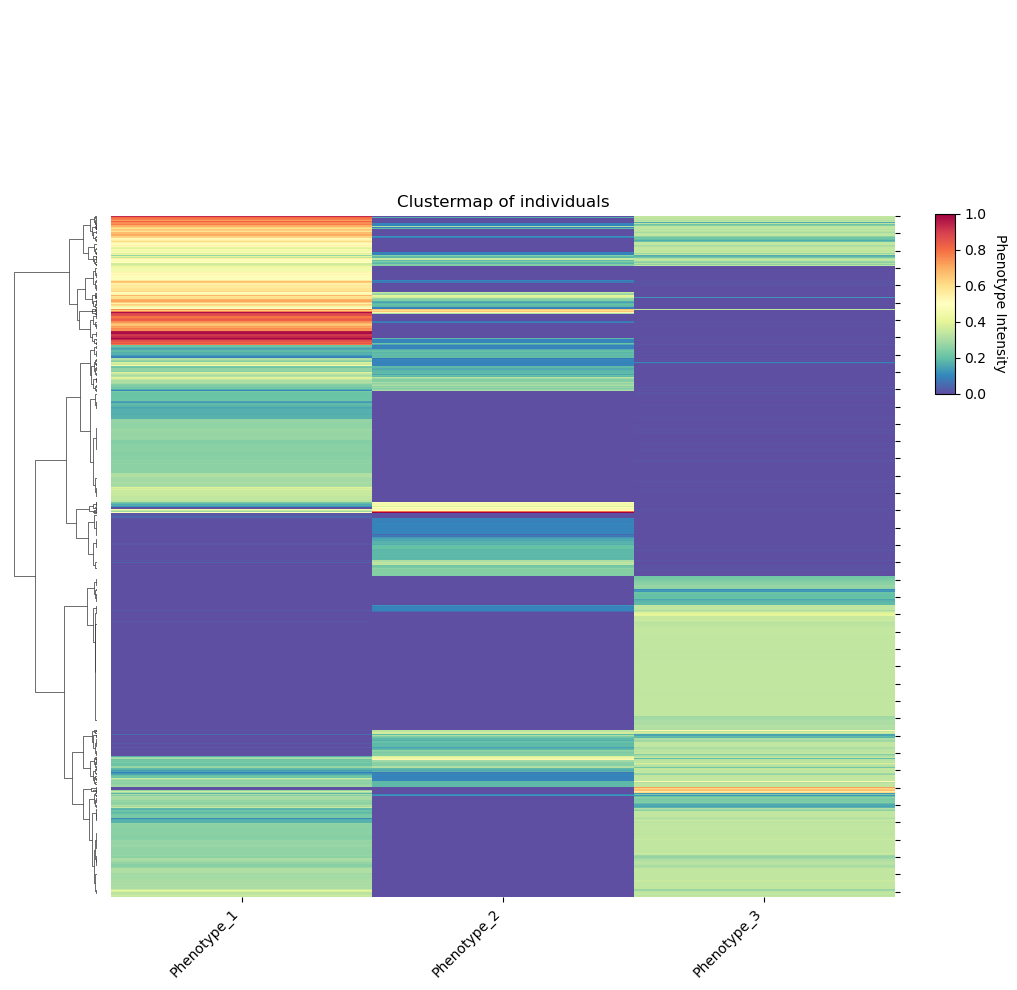

In [80]:
plot_clustermap(phenotype_summary_df_scaled,
                id_col='ID_PATIENT',
                label_to_encoded=None,
                colors = 'Spectral_r',
                alphabet=None,
                states=None, 
                linkage_matrix= linkage_matrix)

In [81]:
def assign_clusters(linkage_matrix, num_clusters):
    """
    Assigne des étiquettes de clusters aux données.

    Args:
        linkage_matrix (np.ndarray): Matrice de linkage.
        num_clusters (int): Nombre de clusters à assigner.

    Returns:
        np.ndarray: Étiquettes des clusters.
    """
    clusters = fcluster(linkage_matrix, num_clusters, criterion='maxclust')
    return clusters

In [88]:
clusters = assign_clusters(linkage_matrix, 4)

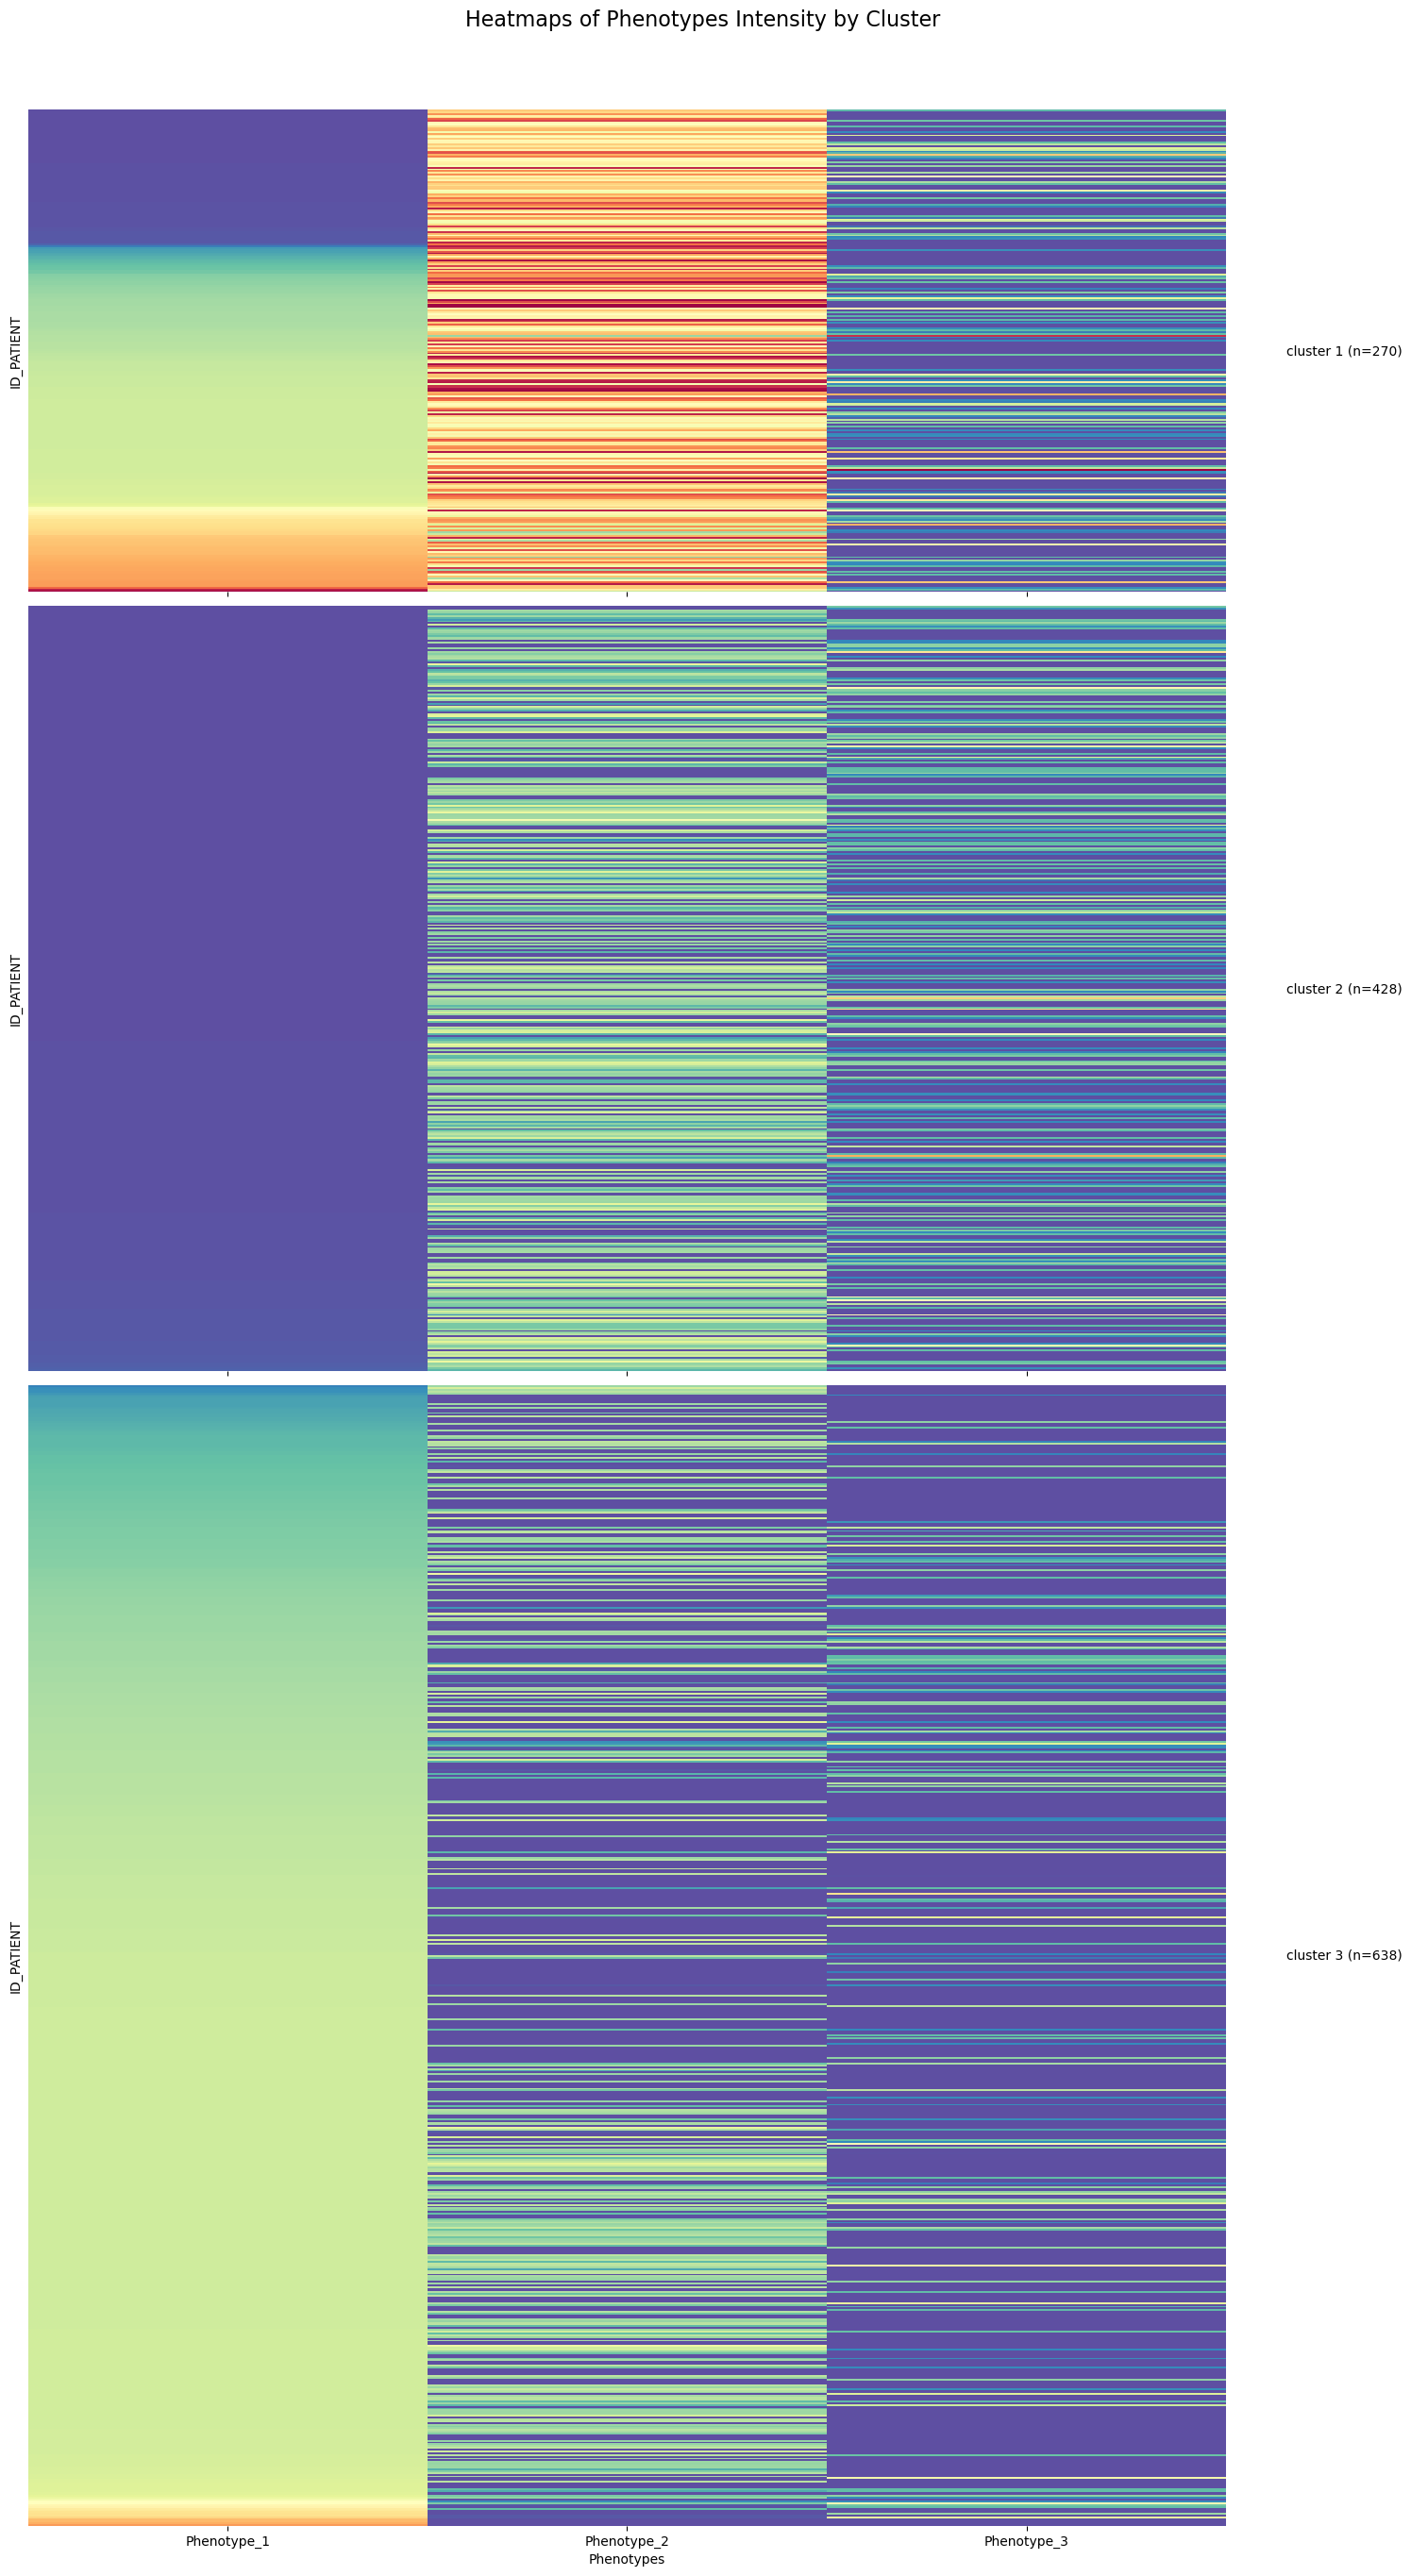

In [ ]:
leaves_order = leaf_order
reordered_data = phenotype_summary_df_scaled.iloc[leaves_order]
reordered_clusters = clusters[leaves_order]

num_clusters = len(np.unique(clusters))
cluster_data = {}
for cluster_label in range(1, num_clusters + 1):
    cluster_indices = np.where(reordered_clusters == cluster_label)[0]
    cluster_df = reordered_data.iloc[cluster_indices]
    if sorted:
        cluster_df = cluster_df.sort_values(by=cluster_df.columns.tolist())
    cluster_data[cluster_label] = cluster_df
    
    heights = [len(cluster_df) for cluster_df in cluster_data.values()]
num_rows = num_clusters
num_cols = min(1, num_clusters)
fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, sum(heights)* 0.02), sharex=True, gridspec_kw={'height_ratios': heights})

# if num_clusters == 2:
#     axs = np.array([axs])
# if num_clusters % 2 != 0:
#     fig.delaxes(axs[-1, -1])  

# viridis_colors_list = [plt.cm.viridis(i) for i in np.linspace(0, 1, len(cluster_data[1].columns))]
# legend_handles = [plt.Rectangle((0, 0), 1, 1, color=viridis_colors_list[i]) for i in range(len(cluster_data[1].columns))]          

# colors = sns.color_palette("viridis", n_colors=len(cluster_data[1].columns))    
vmin, vmax = 0, 1
# plt.figure(figsize=(10, 15))
plt.subplots_adjust(hspace=2, wspace=0.5)
plt.suptitle('Heatmaps of Phenotypes Intensity by Cluster', fontsize=16, y=1.02)
for cluster_label, (cluster_df, ax) in enumerate(zip(cluster_data.items(), axs)):
    #sns.heatmap(cluster_df[1].drop(id_col, axis=1).replace(label_to_encoded), cmap=colors, cbar=False, ax=ax, yticklabels=False)
    heatmap_data = cluster_df[1]
    heatmap_data = heatmap_data.infer_objects(copy=True)
    sns.heatmap(heatmap_data, cmap='Spectral_r', cbar=False, ax=ax, yticklabels=False, 
                vmin=vmin, vmax=vmax)
    ax.tick_params(axis='x')
    ax.text(1.05, 0.5, f'cluster {cluster_label+1} (n={len(cluster_df[1])})', transform=ax.transAxes, ha='left', va='center')
axs[-1].set_xlabel('Phenotypes')


# plt.legend(handles=legend_handles, loc='lower right', ncol=1, title='Statuts')
plt.tight_layout()
plt.show()

In [ ]:
def plot_cluster_heatmaps(data, id_col, label_to_encoded, colors, alphabet, states, clusters, leaf_order, sorted=True, mode=None):
    """
    Plot heatmaps for each cluster, ensuring the data is sorted by leaves_order.

    Parameters:
    data (pd.DataFrame): The dataset containing treatment sequences.
    id_col (str): The column name for patient IDs.
    label_to_encoded (dict): Mapping of labels to encoded values.
    colors (str): Colormap for the heatmap.
    alphabet (list): List of unique treatment states.
    states (list): List of state labels corresponding to the alphabet.
    clusters (numpy.ndarray): The cluster assignments for each patient.
    leaf_order (list): The order of leaves from the hierarchical clustering.
    sorted (bool): Whether to sort the data within each cluster. Default is True.

    Returns:
    None
    """
    data = data.drop(id_col, axis=1)
    
    # Reorder data based on leaf order
    if leaf_order is None or len(leaf_order) == 0:
        reordered_data = data.copy()
        reordered_clusters = clusters
    else:
        leaves_order = leaf_order
        reordered_data = data.iloc[leaves_order]
        reordered_clusters = clusters[leaves_order]

    # Group data by clusters
    num_clusters = len(np.unique(clusters))
    cluster_data = {}
    for cluster_label in range(1, num_clusters + 1):
        cluster_indices = np.where(reordered_clusters == cluster_label)[0]
        cluster_df = reordered_data.iloc[cluster_indices]
        if sorted:
            cluster_df = cluster_df.sort_values(by=cluster_df.columns.tolist())
        cluster_data[cluster_label] = cluster_df

    heights = [len(cluster_df) for cluster_df in cluster_data.values()]
    num_rows = num_clusters
    num_cols = min(1, num_clusters)
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, sum(heights)* 0.02), sharex=True, gridspec_kw={'height_ratios': heights})
    
    if num_clusters == 2:
        axs = np.array([axs])
    # if num_clusters % 2 != 0:
    #     fig.delaxes(axs[-1, -1])  
    # elif     
    
    plt.subplots_adjust(hspace=2, wspace=0.5)
    

    
    if mode == 'unidimensional':
        plt.suptitle('Heatmaps of Treatment Sequences by Cluster', fontsize=16, y=1.02)
        for cluster_label, (cluster_df, ax) in enumerate(zip(cluster_data.items(), axs)):
            #sns.heatmap(cluster_df[1].drop(id_col, axis=1).replace(label_to_encoded), cmap=colors, cbar=False, ax=ax, yticklabels=False)
            heatmap_data = cluster_df[1].drop(id_col, axis=1).replace(label_to_encoded)
            heatmap_data = heatmap_data.infer_objects(copy=True)
            sns.heatmap(heatmap_data, cmap=colors, cbar=False, ax=ax, yticklabels=False)
            ax.tick_params(axis='x', rotation=45)
            ax.text(1.05, 0.5, f'cluster {cluster_label+1} (n={len(cluster_df[1])})', transform=ax.transAxes, ha='left', va='center')
        axs[-1].set_xlabel('Time in months')
        
        # Add a legend for treatment states
        viridis_colors_list = [plt.cm.viridis(i) for i in np.linspace(0, 1, len(alphabet))]
        legend_handles = [plt.Rectangle((0, 0), 1, 1, color=viridis_colors_list[i], label=alphabet[i]) for i in range(len(alphabet))]
        plt.legend(handles=legend_handles, labels=states, loc='lower right', ncol=1, title='Statuts')
        
        plt.tight_layout()
    
    elif mode == 'multidimensional':
        vmin, vmax = 0, 1
        plt.suptitle('Heatmaps of Phenotypes Intensity by Cluster', y=1.02)
        for cluster_label, (cluster_df, ax) in enumerate(zip(cluster_data.items(), axs)):
            heatmap_data = cluster_df[1]
            heatmap_data = heatmap_data.infer_objects(copy=True)
            sns.heatmap(heatmap_data,
                        cmap='Spectral_r',
                        cbar=False,
                        ax=ax,
                        yticklabels=False, 
                        vmin=vmin, vmax=vmax)
            ax.tick_params(axis='x')
            ax.text(1.05, 0.5, f'cluster {cluster_label+1} (n={len(cluster_df[1])})', transform=ax.transAxes, ha='left', va='center')
        axs[-1].set_xlabel('Phenotypes')
        plt.tight_layout()


    else:
        raise ValueError("Invalid mode. Choose either 'unidimensional' or 'multidimensional'.")

    plt.show()

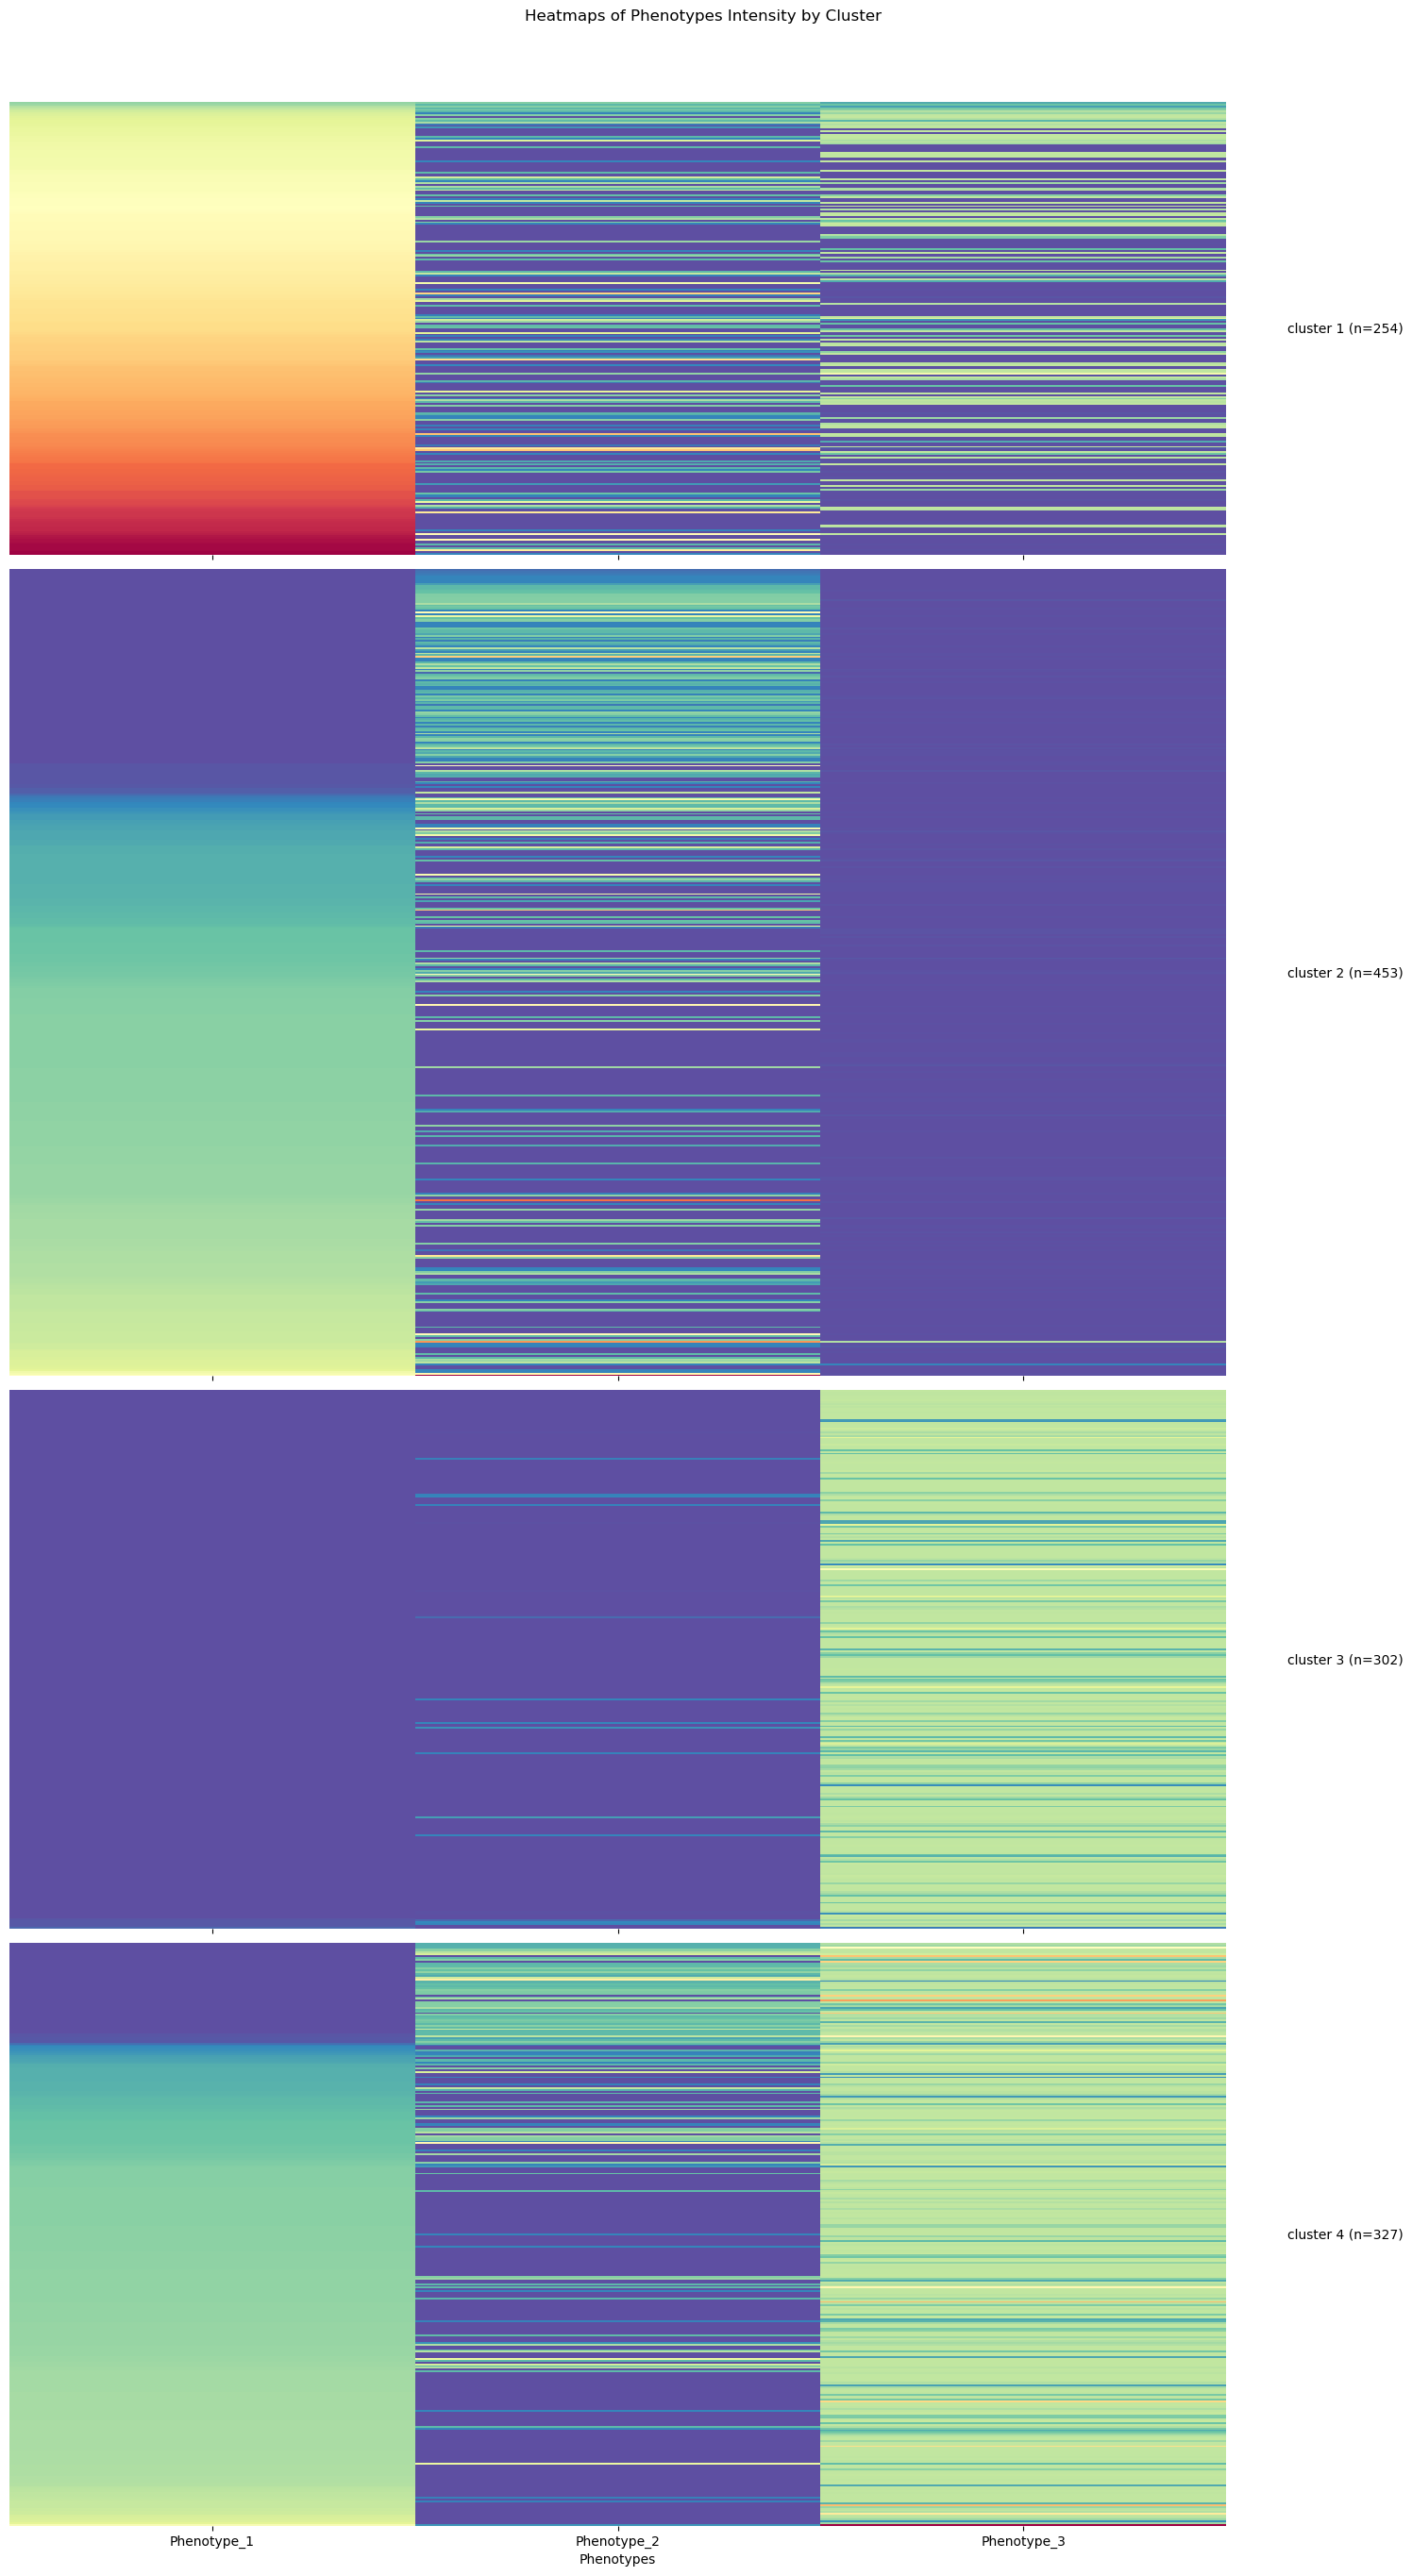

In [90]:
plot_cluster_heatmaps(phenotype_summary_df_scaled, 
                      id_col='ID_PATIENT',
                      label_to_encoded=None,
                      colors='Spectral_r',
                      alphabet=None,
                      states=None, 
                      clusters=clusters,
                      leaf_order=leaf_order,
                      sorted=True, 
                      mode='multidimensional')

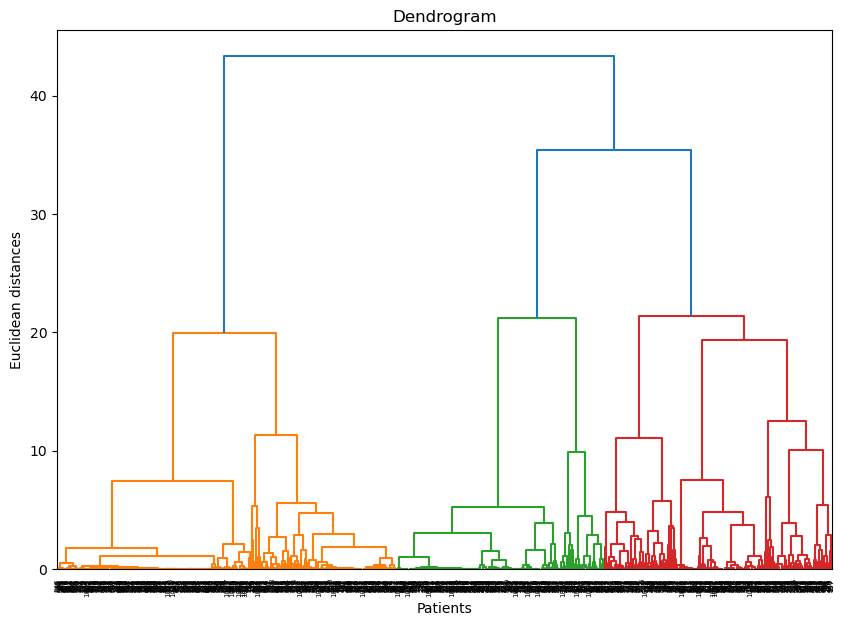

In [292]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch

scaler = StandardScaler()
data_scaled = scaler.fit_transform(phenotype_summary_df.drop(columns=['Patient_ID']))

plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(data_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Patients')
plt.ylabel('Euclidean distances')
plt.show()

In [ ]:
n_clusters = 3 
cah = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='ward')
clusters = cah.fit_predict(data_scaled)

phenotype_summary_df['Cluster'] = clusters
phenotype_summary_df.head()

,Phenotype_1,Phenotype_2,Phenotype_3,Patient_ID,Cluster
0,1.022673,0.010673,1.614332,1101105979,1
1,0.435515,0.010912,1.822512,1101108956,1
2,0.012415,0.005591,1.620209,1101110539,2
3,1.007129,0.005944,0.001166,1102100714,1
4,0.732349,0.563179,1.866680,1102101064,1


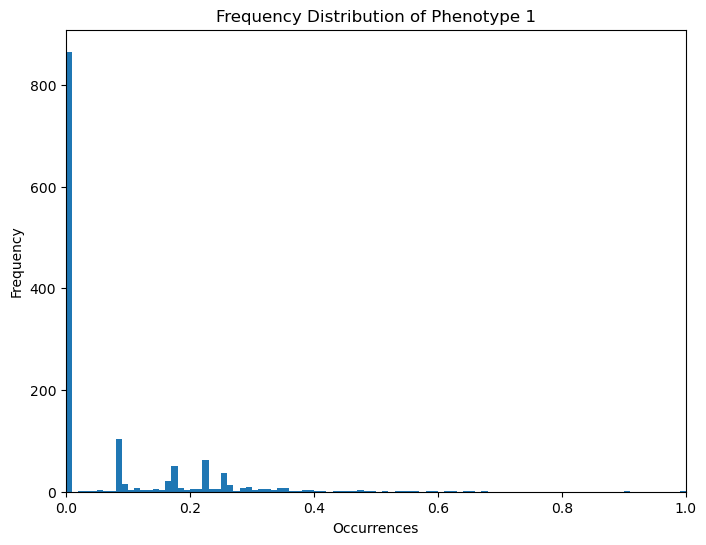

In [73]:
phenotype_summary_df_scaled['Phenotype_1'].plot(kind='hist', bins=100, figsize=(8, 6))
plt.title('Frequency Distribution of Phenotype 1')
plt.xlabel('Occurrences')
plt.ylabel('Frequency')
plt.xlim(0, 1)  # Set the range of the x-axis
plt.show()

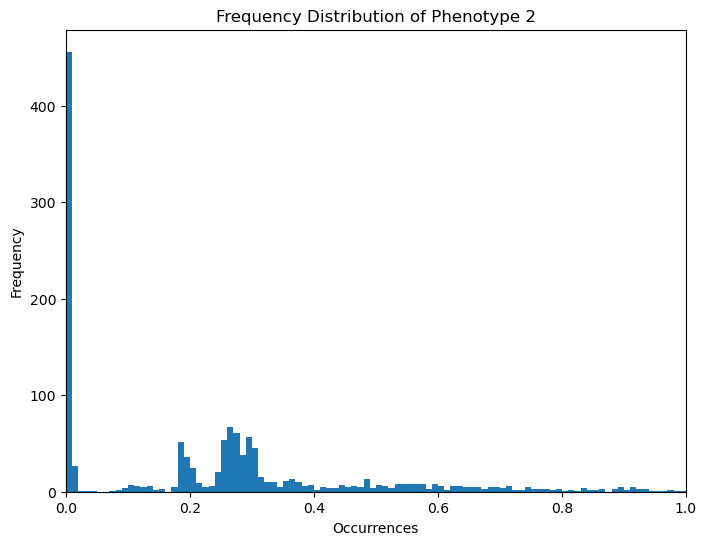

In [74]:
phenotype_summary_df_scaled['Phenotype_2'].plot(kind='hist', bins=100, figsize=(8, 6))
plt.title('Frequency Distribution of Phenotype 2')
plt.xlabel('Occurrences')
plt.ylabel('Frequency')
plt.xlim(0, 1)  # Set the range of the x-axis
plt.show()

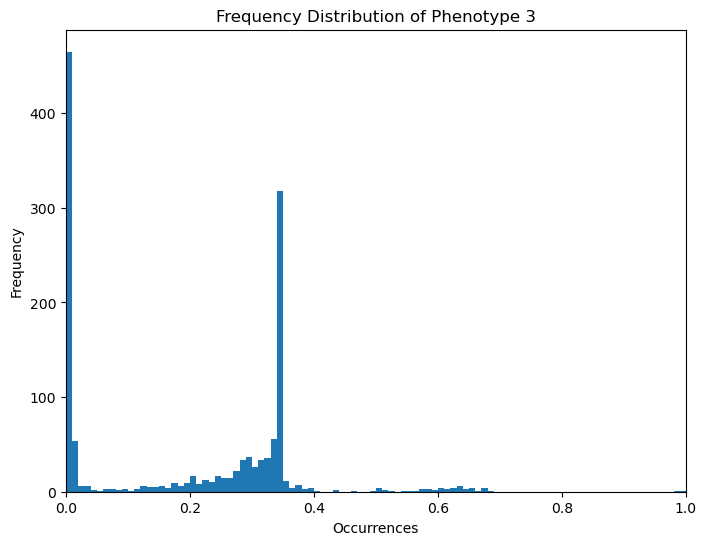

In [75]:
phenotype_summary_df_scaled['Phenotype_3'].plot(kind='hist', bins=100, figsize=(8, 6))
plt.title('Frequency Distribution of Phenotype 3')
plt.xlabel('Occurrences')
plt.ylabel('Frequency')
plt.xlim(0, 1)  # Set the range of the x-axis
plt.show()

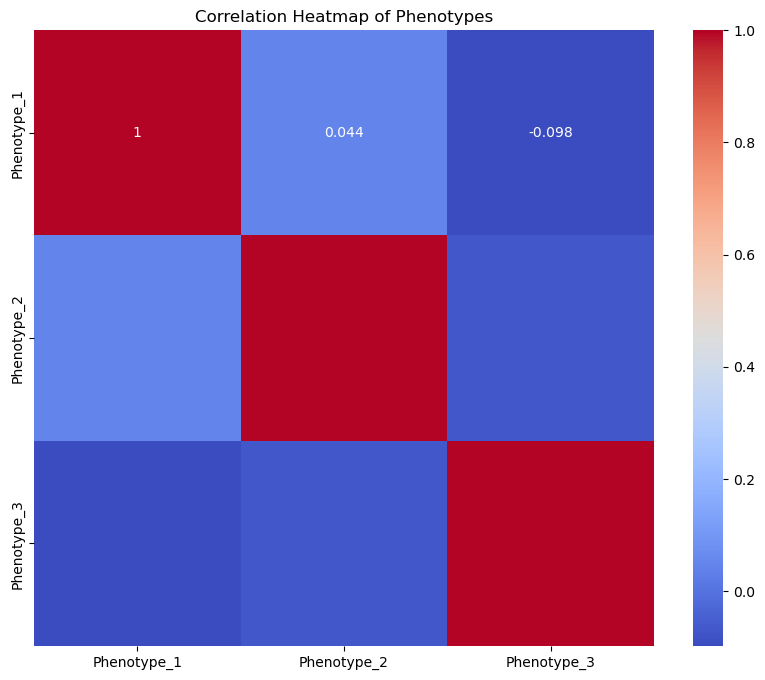

In [77]:
plt.figure(figsize=(10, 8))
sns.heatmap(phenotype_summary_df_scaled.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Phenotypes')
plt.show()

import seaborn as sns

Here are some analytical plots you can create for `phenotype_summary_df`:

1. **Bar Plot**: Show the average or total occurrences of each phenotype across all patients.
    ```python
    phenotype_summary_df.drop(columns=['Patient_ID']).mean().plot(kind='bar', figsize=(10, 6))
    plt.title('Average Occurrences of Each Phenotype')
    plt.xlabel('Phenotypes')
    plt.ylabel('Average Occurrences')
    plt.show()
    ```

2. **Box Plot**: Display the distribution of occurrences for each phenotype.
    ```python
    phenotype_summary_df.drop(columns=['Patient_ID']).plot(kind='box', figsize=(10, 6))
    plt.title('Distribution of Phenotype Occurrences')
    plt.ylabel('Occurrences')
    plt.show()
    ```

3. **Heatmap**: Visualize the correlation between phenotypes.
    ```python
    plt.figure(figsize=(10, 8))
    sns.heatmap(phenotype_summary_df.drop(columns=['Patient_ID']).corr(), annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap of Phenotypes')
    plt.show()
    ```

4. **Histogram**: Show the frequency distribution of occurrences for a specific phenotype.
    ```python
    phenotype_summary_df['Phenotype_1'].plot(kind='hist', bins=20, figsize=(8, 6))
    plt.title('Frequency Distribution of Phenotype 1')
    plt.xlabel('Occurrences')
    plt.ylabel('Frequency')
    plt.show()
    ```

5. **Pair Plot**: Explore pairwise relationships between phenotypes.
    ```python
    sns.pairplot(phenotype_summary_df.drop(columns=['Patient_ID']))
    plt.show()
    ```

    ```python
    sns.clustermap(phenotype_summary_df.drop(columns=['Patient_ID']), cmap='viridis', figsize=(12, 10))
    plt.title('Clustered Heatmap of Phenotypes')
    plt.show()

These plots can help you understand the distribution, relationships, and patterns in the phenotype data.

Number of patients in each cluster:
1    452
0    302
2    275
Name: count, dtype: int64


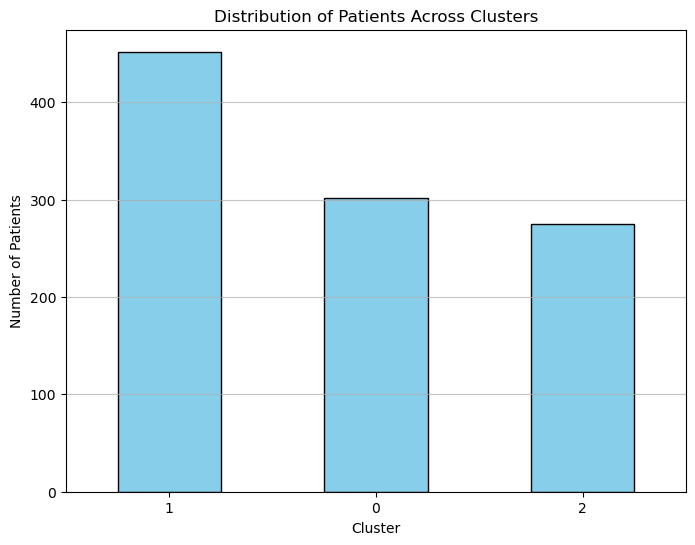

In [295]:
cluster_counts = pd.Series(clusters).value_counts()
print("Number of patients in each cluster:")
print(cluster_counts)

plt.figure(figsize=(8, 6))
cluster_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Patients Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.75)
plt.show()

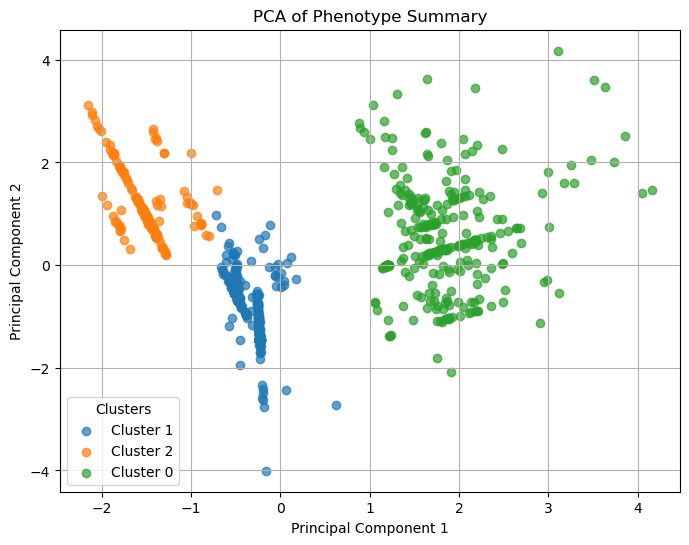

In [ ]:
from sklearn.decomposition import PCA

numerical_data = phenotype_summary_df.drop(columns=['Patient_ID'])
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_data)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['Cluster'] = phenotype_summary_df['Cluster']
pca_df['Patient_ID'] = phenotype_summary_df['Patient_ID']

plt.figure(figsize=(8, 6))
for cluster in pca_df['Cluster'].unique():
    cluster_data = pca_df[pca_df['Cluster'] == cluster]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'], label=f'Cluster {cluster}', alpha=0.7)

plt.title('PCA of Phenotype Summary')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Clusters')
plt.grid(True)
plt.show()

### Poumon

In [389]:
data_poumon = [df[df['ID_PATIENT'].isin(list(CDV_poumon_plus['ID_PATIENT'].values))] for df in data_all]

In [393]:
data_2009_poumon = data_poumon[0].drop_duplicates()
data_2010_poumon = data_poumon[1].drop_duplicates()
data_2011_poumon = data_poumon[2].drop_duplicates()
data_2012_poumon = data_poumon[3].drop_duplicates()
data_2013_poumon = data_poumon[4].drop_duplicates()
data_2014_poumon = data_poumon[5].drop_duplicates()
data_2015_poumon = data_poumon[6].drop_duplicates()
data_2016_poumon = data_poumon[7].drop_duplicates()

df_poumon = pd.concat([data_2009_poumon, data_2010_poumon, data_2011_poumon, data_2012_poumon, data_2013_poumon, data_2014_poumon, data_2015_poumon, data_2016_poumon], ignore_index=True)
# print(df_poumon.ID_PATIENT.nunique())

# convert 'nan' string to NaN
df_poumon = df_poumon.replace('nan', np.nan)

# apply function convert_numeric_date to all columns containing 'DATE_' in their name
for col in df_poumon.columns:
    if 'DATE_' in col :
        df_poumon[col] = df_poumon[col].apply(convert_numeric_date)

df_poumon = df_poumon.dropna(axis=1, how='all')
print(df_poumon.ID_PATIENT.nunique())

394


In [423]:
exemple = df_poumon.merge(CDV_poumon_plus, on='ID_PATIENT', how='left')
exemple['DATE'] = exemple[['DATE_PRESC', 'DATE_DELIV', 'DATE_HOSPIT', 'DATE_ENTREE', 'DATE_SORTIE']].bfill(axis=1).iloc[:, 0]
exemple['AGE_HOSPIT'] = (pd.to_datetime(exemple['DATE_HOSPIT']) - pd.to_datetime(exemple['FC_DateNaissance'])).dt.days // 365

In [440]:
exemple1 = exemple[exemple.ID_PATIENT == '1162409535'].dropna(subset=['DATE'])
exemple1 = exemple1.sort_values(by=['DATE'])
exemple1 = exemple1[exemple1['DATE']>='2016-07-18']

In [447]:
cols = ['ID_PATIENT', 'DATE','DATE_HOSPIT','DATE_PRESC','DATE_DELIV','LIB_PREST','LIB_SPE','QUANTITE','LIB_DIAG_PRINC','LIB_DIAG_REL','LIB_DIAG','LIB_ACTE','LIB_BIO','LIB_CCAM','ACTIVITE_CCAM','LIB_CAT_ETAB','LIB_GHS','LIB_LPP','LIB_CIP','LIB_ATC','LIB_EPH']

In [449]:
exemple1[cols].to_excel((os.path.join(folder_path0, 'exemple1.xlsx')), index=False)

In [435]:
cols_to_keep = ['ID_PATIENT', 'DATE', 'DATE_PRESC', 'DATE_DELIV', 'DATE_HOSPIT', 'DATE_ENTREE', 'DATE_SORTIE', 'AGE_HOSPIT'] 
exemple1[cols_to_keep].dropna(subset=['DATE'])  

,ID_PATIENT,DATE,DATE_PRESC,DATE_DELIV,DATE_HOSPIT,DATE_ENTREE,DATE_SORTIE,AGE_HOSPIT
0,1162409535,2010-02-25,2010-02-25,2010-03-02,NaT,NaT,NaT,NaN
1,1162409535,2010-02-25,2010-02-25,2010-03-02,NaT,NaT,NaT,NaN
2,1162409535,2010-02-25,2010-02-25,2010-03-02,NaT,NaT,NaT,NaN
3,1162409535,2010-02-25,2010-02-25,2010-03-02,NaT,NaT,NaT,NaN
4,1162409535,2010-02-25,2010-02-25,2010-03-02,NaT,NaT,NaT,NaN
...,...,...,...,...,...,...,...,...
650,1162409535,2016-12-27,2016-12-27,2016-12-27,NaT,NaT,NaT,NaN
651,1162409535,2016-12-27,2016-12-27,2016-12-27,NaT,NaT,NaT,NaN
652,1162409535,2016-12-27,2016-12-27,2016-12-27,NaT,NaT,NaT,NaN
653,1162409535,2016-12-27,2016-12-27,2016-12-27,NaT,NaT,NaT,NaN


In [428]:
exemple1.iloc[575632:575656]

,DATE


In [ ]:
df_poumon_subset = df_poumon.merge(
    CDV_poumon_plus[['ID_PATIENT', 'FC_Sexe', 'FC_AgeDiag_R0']],
    on='ID_PATIENT',
    how='left'
).dropna(subset=['FC_Sexe', 'FC_AgeDiag_R0'])
df_poumon_subset.reset_index(drop=True, inplace=True)
df_poumon_subset

,ID_PATIENT,DATE_PRESC,DATE_DELIV,CODE_CCAM,CODE_ATC,FC_Sexe,FC_AgeDiag_R0
0,1101106164,2009-02-05,2009-02-05,NaN,A01AB03,2.0,39.0
1,1101106164,2009-02-05,2009-02-05,NaN,N02AC54,2.0,39.0
2,1101106164,2009-02-05,2009-02-05,NaN,J01RA04,2.0,39.0
3,1101106164,2009-03-13,2009-03-19,NaN,A01AB11,2.0,39.0
4,1101106164,2009-03-13,2009-03-19,NaN,N02AC54,2.0,39.0
...,...,...,...,...,...,...,...
194808,2394100059,2016-12-17,2016-12-17,NaN,,1.0,56.0
194809,2394100059,2016-12-17,2016-12-17,NaN,N06AB03,1.0,56.0
194810,2394100059,2016-12-17,2016-12-17,NaN,R03AC02,1.0,56.0
194811,2394100059,2016-12-17,2016-12-17,NaN,R03BB04,1.0,56.0


In [ ]:
df_poumon_subset.ID_PATIENT.nunique()
# df_poumon_subset[['ID_PATIENT','FC_Sexe']].drop_duplicates()

394

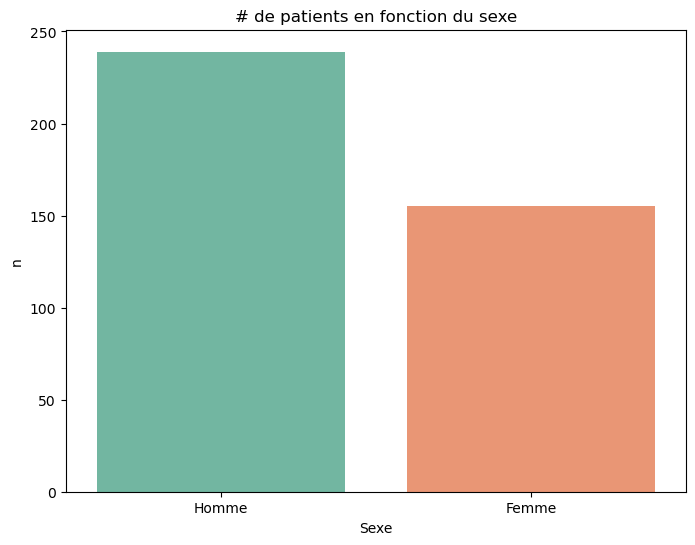

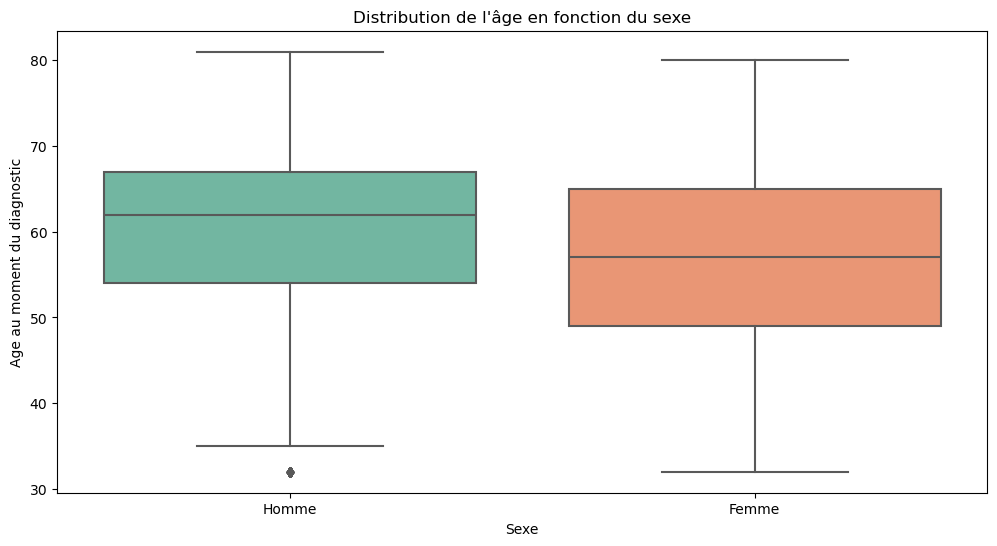

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the count of patients by sex
plt.figure(figsize=(8, 6))
sns.countplot(data=df_poumon_subset[['ID_PATIENT','FC_Sexe']].drop_duplicates(), x='FC_Sexe', palette='Set2')
plt.xticks([0, 1], ['Homme', 'Femme'])
plt.title('# de patients en fonction du sexe')
plt.xlabel('Sexe')
plt.ylabel('n')
plt.show()

# Plot the distribution of age by sex
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_poumon_subset, x='FC_Sexe', y='FC_AgeDiag_R0', palette='Set2')
plt.xticks([0, 1], ['Homme', 'Femme'])
plt.title('Distribution de l\'âge en fonction du sexe')
plt.xlabel('Sexe')
plt.ylabel('Age au moment du diagnostic')
plt.show()

### liste_analytique_ccam_descriptive_a_usage_pmsi_v5_2016

In [ ]:
liste_ccam_2016 = pd.read_excel(r'C:\\Users\\nicolas.grevet\\Downloads\\liste_analytique_ccam_descriptive_a_usage_pmsi_v5_2016.xls', sheet_name='CCAM_Final_2017')

# remove the rows with NaN in the first column
liste_ccam_2016 = liste_ccam_2016.dropna(subset=[liste_ccam_2016.columns[0]])
#remove the columns
liste_ccam_2016 = liste_ccam_2016.drop(liste_ccam_2016.columns[[1, 4, 5, 6, 7, 8, 9, 10]], axis=1)
#rename the columns
liste_ccam_2016.columns = ['Subdivision', 'CODE_CCAM', 'LIB_ACTE']
#apply string type to Subdivision and CODE_CCAM
liste_ccam_2016['Subdivision'] = liste_ccam_2016['Subdivision'].astype(str)
#remove duplicates in Subdivision
liste_ccam_2016 = liste_ccam_2016.drop_duplicates(subset=['Subdivision'])
liste_ccam_2016.reset_index(drop=True, inplace=True)  

liste_ccam_2016

,Subdivision,CODE_CCAM,LIB_ACTE
0,01,NaN,"SYSTÈME NERVEUX CENTRAL, PÉRIPHÉRIQUE ET AUTONOME"
1,01.01,NaN,ACTES DIAGNOSTIQUES SUR LE SYSTÈME NERVEUX
2,01.01.01,NaN,Explorations électrophysiologiques du système ...
3,01.01.01.01,NaN,Électromyographie [EMG]
4,AHQP001,AHQP001,"Électromyographie par électrode de surface, sa..."
...,...,...,...
9839,B,B,Majoration du tarif pour acte de radiographie ...
9840,H,H,"Modificateur numérique pour radiothérapie, niv..."
9841,Q,Q,"Modificateur numérique pour radiothérapie, niv..."
9842,V,V,"Modificateur numérique pour radiothérapie, niv..."


In [ ]:
for idx, char in enumerate(liste_ccam_2016.Subdivision):
    if char in ['6','7','8']:
        liste_ccam_2016.drop(idx, inplace=True)
    else:
        if len(char.split('.')) == 1 and pd.isna(liste_ccam_2016.loc[idx,'CODE_CCAM']):
            liste_ccam_2016.loc[idx,'Niveau1'] = char.split('.')[0]
        elif len(char.split('.')) == 2 and pd.isna(liste_ccam_2016.loc[idx,'CODE_CCAM']):
            liste_ccam_2016.loc[idx,'Niveau1'] = char.split('.')[0]
            liste_ccam_2016.loc[idx,'Niveau2'] = char.split('.')[1]    
        elif len(char.split('.')) == 3 and pd.isna(liste_ccam_2016.loc[idx,'CODE_CCAM']):
            liste_ccam_2016.loc[idx,'Niveau1'] = char.split('.')[0]
            liste_ccam_2016.loc[idx,'Niveau2'] = char.split('.')[1]
            liste_ccam_2016.loc[idx,'Niveau3'] = char.split('.')[2]
        elif len(char.split('.')) == 4 and pd.isna(liste_ccam_2016.loc[idx,'CODE_CCAM']):
            liste_ccam_2016.loc[idx,'Niveau1'] = char.split('.')[0]
            liste_ccam_2016.loc[idx,'Niveau2'] = char.split('.')[1]
            liste_ccam_2016.loc[idx,'Niveau3'] = char.split('.')[2]
            liste_ccam_2016.loc[idx,'Niveau4'] = char.split('.')[3]
        elif len(char.split('.')) == 1 and pd.notna(liste_ccam_2016.loc[idx,'CODE_CCAM']):
            last_row_with_len_3 = liste_ccam_2016[(liste_ccam_2016['Niveau3'].notna()) & (liste_ccam_2016.index < idx)].iloc[-1]
            liste_ccam_2016.loc[idx, 'Niveau1'] = last_row_with_len_3['Niveau1']
            liste_ccam_2016.loc[idx, 'Niveau2'] = last_row_with_len_3['Niveau2']
            liste_ccam_2016.loc[idx, 'Niveau3'] = last_row_with_len_3['Niveau3']

liste_ccam_2016.reset_index(drop=True, inplace=True)

# for idx in range(len(liste_ccam_2016) - 1):
#     if pd.notna(liste_ccam_2016.loc[idx, 'Niveau2']) and pd.isna(liste_ccam_2016.loc[idx, 'Niveau3']) and pd.isna(liste_ccam_2016.loc[idx + 1, 'Niveau3']):
#         liste_ccam_2016.loc[idx, 'CODE_CCAM'] = 'Niv. inter'            

liste_ccam_2016.replace('na', np.nan, inplace=True)    
liste_ccam_2016 = liste_ccam_2016[liste_ccam_2016['Niveau4'].isna()]

#In column 'code_ccam' replace all the non missing-values with the values from 'Subdivision'
liste_ccam_2016.loc[liste_ccam_2016['CODE_CCAM'].notna(), 'CODE_CCAM'] = liste_ccam_2016.loc[liste_ccam_2016['CODE_CCAM'].notna(), 'Subdivision']

# Find the index of the row where Niveau1 = '19' and Niveau2 = '03'
drop_index = liste_ccam_2016[(liste_ccam_2016['Niveau1'] == '19') & (liste_ccam_2016['Niveau2'] == '03')].index
if not drop_index.empty:
    liste_ccam_2016 = liste_ccam_2016.loc[:drop_index[0]]

liste_ccam_2016.reset_index(drop=True, inplace=True)  
liste_ccam_2016

,Subdivision,CODE_CCAM,LIB_ACTE,Niveau1,Niveau2,Niveau3,Niveau4
0,01,NaN,"SYSTÈME NERVEUX CENTRAL, PÉRIPHÉRIQUE ET AUTONOME",01,NaN,NaN,NaN
1,01.01,NaN,ACTES DIAGNOSTIQUES SUR LE SYSTÈME NERVEUX,01,01,NaN,NaN
2,01.01.01,NaN,Explorations électrophysiologiques du système ...,01,01,01,NaN
3,AHQP001,AHQP001,"Électromyographie par électrode de surface, sa...",01,01,01,NaN
4,AHQP002,AHQP002,"Électromyographie par électrode de surface, av...",01,01,01,NaN
...,...,...,...,...,...,...,...
8777,YYYY284,YYYY284,Supplément pour pose de 12 dents contreplaquée...,19,02,11,NaN
8778,YYYY236,YYYY236,Supplément pour pose de 13 dents contreplaquée...,19,02,11,NaN
8779,YYYY353,YYYY353,Supplément pour pose de 14 dents contreplaquée...,19,02,11,NaN
8780,YYYY465,YYYY465,Supplément pour examen spécifique préalable et...,19,02,11,NaN


In [ ]:
liste_ccam_2016[liste_ccam_2016['CODE_CCAM'].shift(-1).isna() | liste_ccam_2016['CODE_CCAM'].shift(1).isna() | liste_ccam_2016['CODE_CCAM'].notna()]

,Subdivision,CODE_CCAM,LIB_ACTE,Niveau1,Niveau2,Niveau3,Niveau4
0,01,NaN,"SYSTÈME NERVEUX CENTRAL, PÉRIPHÉRIQUE ET AUTONOME",01,NaN,NaN,NaN
1,01.01,NaN,ACTES DIAGNOSTIQUES SUR LE SYSTÈME NERVEUX,01,01,NaN,NaN
2,01.01.01,NaN,Explorations électrophysiologiques du système ...,01,01,01,NaN
3,AHQP001,AHQP001,"Électromyographie par électrode de surface, sa...",01,01,01,NaN
4,AHQP002,AHQP002,"Électromyographie par électrode de surface, av...",01,01,01,NaN
...,...,...,...,...,...,...,...
8777,YYYY284,YYYY284,Supplément pour pose de 12 dents contreplaquée...,19,02,11,NaN
8778,YYYY236,YYYY236,Supplément pour pose de 13 dents contreplaquée...,19,02,11,NaN
8779,YYYY353,YYYY353,Supplément pour pose de 14 dents contreplaquée...,19,02,11,NaN
8780,YYYY465,YYYY465,Supplément pour examen spécifique préalable et...,19,02,11,NaN


In [ ]:
# Identify rows where the next row has a missing value in the column CODE_CCAM (except row where is not missing in CODE_CCAM)

rows_to_keep =  (
    (liste_ccam_2016['CODE_CCAM'].shift(-1).notna() | liste_ccam_2016['CODE_CCAM'].shift(1).notna()) &
    (liste_ccam_2016['CODE_CCAM'].shift(-1).isna() | liste_ccam_2016['CODE_CCAM'].shift(1).isna() | liste_ccam_2016['CODE_CCAM'].notna())
    )

# Filter the DataFrame to keep only the desired rows
filtered_test = liste_ccam_2016[rows_to_keep].reset_index(drop=True)

filtered_test

,Subdivision,CODE_CCAM,LIB_ACTE,Niveau1,Niveau2,Niveau3,Niveau4
0,01.01.01,NaN,Explorations électrophysiologiques du système ...,01,01,01,NaN
1,AHQP001,AHQP001,"Électromyographie par électrode de surface, sa...",01,01,01,NaN
2,AHQP002,AHQP002,"Électromyographie par électrode de surface, av...",01,01,01,NaN
3,AHQB027,AHQB027,Électromyographie de 1 ou 2 muscles striés au ...,01,01,01,NaN
4,AHQB025,AHQB025,Électromyographie de 1 ou 2 muscles striés au ...,01,01,01,NaN
...,...,...,...,...,...,...,...
8248,YYYY284,YYYY284,Supplément pour pose de 12 dents contreplaquée...,19,02,11,NaN
8249,YYYY236,YYYY236,Supplément pour pose de 13 dents contreplaquée...,19,02,11,NaN
8250,YYYY353,YYYY353,Supplément pour pose de 14 dents contreplaquée...,19,02,11,NaN
8251,YYYY465,YYYY465,Supplément pour examen spécifique préalable et...,19,02,11,NaN


In [ ]:
# Rows with values in Niveau3
dataset_with_niveau3 = filtered_test[filtered_test['Niveau3'].notna()]

# Rows with missing values in Niveau3
dataset_without_niveau3 = filtered_test[filtered_test['Niveau3'].isna()]

# Display the shapes of the resulting datasets
print(f"Rows with Niveau3: {dataset_with_niveau3.shape[0]}")
print(f"Rows without Niveau3: {dataset_without_niveau3.shape[0]}")

Rows with Niveau3: 8110
Rows without Niveau3: 143


In [ ]:
# Group the rows by Niveau1, Niveau2, and Niveau3
grouped_without_niveau3 = dataset_without_niveau3.groupby(['Niveau1', 'Niveau2'])

# Extract the CODE_CCAM for each group
code_ccam_by_group_without_niveau3 = grouped_without_niveau3['CODE_CCAM'].apply(list).reset_index()

# Remove NaN values from the lists in the 'CODE_CCAM' column
code_ccam_by_group_without_niveau3['CODE_CCAM'] = code_ccam_by_group_without_niveau3['CODE_CCAM'].apply(lambda x: [i for i in x if pd.notna(i)])

# Add the LIB_ACTE corresponding to Niveau1 and Niveau2
code_ccam_by_group_without_niveau3['LIB_ACTE'] = code_ccam_by_group_without_niveau3.apply(
    lambda row: liste_ccam_2016[
        (liste_ccam_2016['Niveau1'] == row['Niveau1']) & 
        (liste_ccam_2016['Niveau2'] == row['Niveau2'])
    ]['LIB_ACTE'].values[0] if not liste_ccam_2016[
        (liste_ccam_2016['Niveau1'] == row['Niveau1']) & 
        (liste_ccam_2016['Niveau2'] == row['Niveau2'])
    ]['LIB_ACTE'].empty else None, axis=1
)

# Display the resulting DataFrame
group1 = code_ccam_by_group_without_niveau3[code_ccam_by_group_without_niveau3['CODE_CCAM'].str.len() > 0]
group1

,Niveau1,Niveau2,CODE_CCAM,LIB_ACTE
5,01,07,"[ANMP001, ANLP002, AZRP001, ANRP001, ANLB003]",AUTRES ACTES THÉRAPEUTIQUES SUR LE SYSTÈME NER...
30,07,07,"[HSLF002, HSLF003, HSLD001, HSLD002, HSLF001]",SUPPLÉANCE NUTRITIONNELLE
34,08,05,"[JZNP002, JZNP001, JZNP003, QBFA014]",ACTES THÉRAPEUTIQUES SUR LE PÉRINÉE MASCULIN E...
37,08,08,"[JVRP004, JVRP008, JVRP007, JVJF003, JVJF004, ...",ÉPURATION EXTRARÉNALE
38,09,02,"[JKHD002, JKHD003, JJFJ001, JJFC011, JHFB001, ...",ASSISTANCE MÉDICALE À LA PROCRÉATION
40,09,04,"[JQJB001, JQCB001, JQLF003, JQLF001, JQLF002]",ACTES THÉRAPEUTIQUES CHEZ LE FOETUS
41,09,05,"[GEJD001, GLLD018, GLLD016, ZZEP004, ZZEP002, ...",ACTES THÉRAPEUTIQUES CHEZ LE NOUVEAU-NÉ À LA N...
45,11,04,"[LCPA001, LCFA001, LCFA002, LCMA001, LCLB001]",ACTES THÉRAPEUTIQUES SUR LES MUSCLES DE LA TÊTE
69,18,01,"[ZZLP025, ZZLP030, ZZLP054, ZZLP042, ZZLP008, ...","GESTES D'ANESTHÉSIE GÉNÉRALE OU LOCORÉGIONALE,..."


In [ ]:
# Group the rows by Niveau1, Niveau2, and Niveau3
grouped_with_niveau3 = dataset_with_niveau3.groupby(['Niveau1', 'Niveau2', 'Niveau3'])

# Extract the CODE_CCAM for each group
code_ccam_by_group_with_niveau3 = grouped_with_niveau3['CODE_CCAM'].apply(list).reset_index()

# Remove NaN values from the lists in the 'CODE_CCAM' column
code_ccam_by_group_with_niveau3['CODE_CCAM'] = code_ccam_by_group_with_niveau3['CODE_CCAM'].apply(lambda x: [i for i in x if pd.notna(i)])

# Add the LIB_ACTE corresponding to Niveau1 and Niveau2
code_ccam_by_group_with_niveau3['LIB_ACTE'] = code_ccam_by_group_with_niveau3.apply(
    lambda row: liste_ccam_2016[
        (liste_ccam_2016['Niveau1'] == row['Niveau1']) & 
        (liste_ccam_2016['Niveau2'] == row['Niveau2']) &
        (liste_ccam_2016['Niveau3'] == row['Niveau3'])
    ]['LIB_ACTE'].values[0] if not liste_ccam_2016[
        (liste_ccam_2016['Niveau1'] == row['Niveau1']) & 
        (liste_ccam_2016['Niveau2'] == row['Niveau2']) & 
        (liste_ccam_2016['Niveau3'] == row['Niveau3'])
    ]['LIB_ACTE'].empty else None, axis=1
)

# Display the resulting DataFrame
group2 = code_ccam_by_group_with_niveau3[code_ccam_by_group_with_niveau3['CODE_CCAM'].str.len() > 0]
group2

,Niveau1,Niveau2,Niveau3,CODE_CCAM,LIB_ACTE
0,01,01,01,"[AHQP001, AHQP002, AHQB027, AHQB025, AHQB024, ...",Explorations électrophysiologiques du système ...
1,01,01,02,"[ABLB001, ABLB002, ABLB003, AFLB004, ABGA001, ...",Étude des pressions du système nerveux
2,01,01,03,"[AAQM002, AEQM001]",Échographie du système nerveux
3,01,01,04,"[AEQH002, AEQH001, AFQH003, AFQH002, AFQH001]",Radiographie du système nerveux
4,01,01,05,"[ACQK001, ACQH003, ACQH001, ACQK003, ACQH002, ...",Scanographie du système nerveux
...,...,...,...,...,...
522,19,02,05,"[YYYY146, YYYY189, YYYY456]",Neurologie
523,19,02,06,"[YYYY058, YYYY186, YYYY232, YYYY025]",Pneumologie
524,19,02,07,"[YYYY065, YYYY425, YYYY145, YYYY212, YYYY410, ...",Radiologie
525,19,02,08,"[YYYY109, YYYY128, YYYY151, YYYY166]",Radiothérapie


In [ ]:
code_ccam_by_group_with_niveau3[code_ccam_by_group_with_niveau3['LIB_ACTE'] == 'Néphrologie']

,Niveau1,Niveau2,Niveau3,CODE_CCAM,LIB_ACTE
518,19,01,14,[],Néphrologie


In [ ]:
# Combine the two dataframes: code_ccam_by_group_with_niveau3 and code_ccam_by_group_without_niveau3
combined_code_ccam = pd.concat([group1, group2])

# Generate a dictionary with LIB_ACTE as keys and CODE_CCAM as values
lib_acte_to_code_ccam = combined_code_ccam.set_index('LIB_ACTE')['CODE_CCAM'].to_dict()

# Display the resulting dictionary
lib_acte_to_code_ccam

{'AUTRES ACTES THÉRAPEUTIQUES SUR LE SYSTÈME NERVEUX': ['ANMP001',
  'ANLP002',
  'AZRP001',
  'ANRP001',
  'ANLB003'],
 'SUPPLÉANCE NUTRITIONNELLE': ['HSLF002',
  'HSLF003',
  'HSLD001',
  'HSLD002',
  'HSLF001'],
 'ACTES THÉRAPEUTIQUES SUR LE PÉRINÉE MASCULIN ET FÉMININ': ['JZNP002',
  'JZNP001',
  'JZNP003',
  'QBFA014'],
 'ÉPURATION EXTRARÉNALE': ['JVRP004',
  'JVRP008',
  'JVRP007',
  'JVJF003',
  'JVJF004',
  'JVJF008',
  'JVJB001',
  'JVJF002',
  'JVJF006',
  'JVJF005',
  'JVJF007',
  'JVJB002'],
 'ASSISTANCE MÉDICALE À LA PROCRÉATION': ['JKHD002',
  'JKHD003',
  'JJFJ001',
  'JJFC011',
  'JHFB001',
  'JSLD002',
  'JSLD001',
  'JSEC001',
  'JSED001'],
 'ACTES THÉRAPEUTIQUES CHEZ LE FOETUS': ['JQJB001',
  'JQCB001',
  'JQLF003',
  'JQLF001',
  'JQLF002'],
 'ACTES THÉRAPEUTIQUES CHEZ LE NOUVEAU-NÉ À LA NAISSANCE': ['GEJD001',
  'GLLD018',
  'GLLD016',
  'ZZEP004',
  'ZZEP002',
  'ZZEP003',
  'ZCLA001',
  'EPLF001'],
 'ACTES THÉRAPEUTIQUES SUR LES MUSCLES DE LA TÊTE': ['LCPA001',
 

### to_delete

In [91]:
folder_path_bike = 'C:/Users/nicolas.grevet/Desktop/VICAN2/'
datafile=open(folder_path_bike+'BIKE.txt')

voc=set()
sequences=[]
for line in datafile:
    sequence=line.rstrip(' -2\n').split('-1')[:-1]
    sequence = [ int(s) for s in sequence ]
    # print(sequence)
    voc=voc.union(set(sequence))
    if len(sequence)>5:
        sequences.append(sequence)

#recodage of the sequences
codage={}
for e in voc:
    codage[e]=len(codage)
codage

{3074: 0,
 3075: 1,
 3076: 2,
 3077: 3,
 3078: 4,
 3079: 5,
 3080: 6,
 3081: 7,
 3082: 8,
 4108: 9,
 3000: 10,
 3005: 11,
 3006: 12,
 3007: 13,
 3008: 14,
 3009: 15,
 3010: 16,
 3011: 17,
 3014: 18,
 3016: 19,
 3018: 20,
 3019: 21,
 3020: 22,
 3021: 23,
 3022: 24,
 3023: 25,
 3024: 26,
 3025: 27,
 3026: 28,
 3027: 29,
 3028: 30,
 3029: 31,
 3030: 32,
 3031: 33,
 3032: 34,
 3033: 35,
 3034: 36,
 3035: 37,
 3036: 38,
 3037: 39,
 3038: 40,
 3039: 41,
 3040: 42,
 3042: 43,
 3045: 44,
 3046: 45,
 3047: 46,
 3048: 47,
 3049: 48,
 3051: 49,
 3052: 50,
 3053: 51,
 3054: 52,
 3055: 53,
 3056: 54,
 3057: 55,
 3058: 56,
 3059: 57,
 3060: 58,
 3062: 59,
 3063: 60,
 3064: 61,
 3065: 62,
 3066: 63,
 3067: 64,
 3068: 65,
 3069: 66}

In [92]:
recoded=[]
for seq in sequences:
    recoded.append( [codage[e] for e in seq ] )

recoded    

[[20, 65, 18, 65, 30, 62, 19],
 [32, 23, 1, 33, 37, 42, 37],
 [19, 35, 32, 43, 13, 40, 18],
 [40, 11, 39, 11, 53, 32],
 [12, 50, 48, 35, 48, 32, 40, 18],
 [36, 37, 11, 1, 34, 5],
 [1, 11, 59, 23, 32, 14, 11],
 [60, 11, 42, 50, 50, 50, 37, 50, 12],
 [18, 18, 62, 38, 24, 12, 53, 60],
 [36, 19, 18, 18, 18, 43, 19, 12],
 [59, 12, 12, 34, 0, 12],
 [6, 21, 21, 22, 64, 23, 5],
 [24, 18, 37, 30, 32, 19, 43],
 [12, 24, 30, 14, 33, 14, 11],
 [34, 34, 60, 36, 12, 0, 12, 33],
 [2, 40, 31, 43, 32, 52, 43, 60],
 [2, 59, 43, 43, 32, 62, 24, 25, 48],
 [50, 65, 30, 43, 64, 33],
 [66, 11, 33, 33, 32, 64, 24, 33],
 [19, 32, 66, 66, 21, 23],
 [55, 63, 62, 63, 33, 33, 36, 33],
 [53, 53, 18, 18, 53, 56, 53],
 [18, 18, 18, 29, 37, 33, 33],
 [43, 48, 12, 43, 18, 59, 23],
 [50, 13, 32, 62, 24, 25],
 [39, 24, 56, 39, 48, 66, 33, 12, 18, 18, 1, 33],
 [40, 38, 23, 18, 25, 12, 14, 33],
 [13, 36, 37, 36, 46, 46],
 [46, 32, 20, 21, 60, 4, 43, 4, 23, 13],
 [32, 36, 23, 64, 14, 33, 19, 33],
 [64, 64, 14, 33, 34, 33, 3

In [94]:
X=[]
for seq in recoded:
    items=[]
    for e in seq:
        item=np.zeros( (1,len(voc)), dtype=np.float64 )
        item[0,e]=1
        items.append(item)
    X.append( torch.from_numpy(np.concatenate(items,axis=0)).transpose(0,1) )
    
    break
X

[tensor([[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 1., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 1.],
         [1., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0.,

In [68]:
#check dimension
torch.sum(X[-1])

tensor(9., dtype=torch.float64)

In [69]:
import pickle

#save the dataset to use it with swotted
W_ = [None] * len(X)
Ph_=None
params={}
pickle.dump([W_, Ph_, X, params], open(f"bike.pkl", "wb"))

In [ ]:
# # Concatenate all the table_ccam from 2009 to 2016 along axis 0
# table_ccam_poumon = pd.concat(data_ccam, axis=0).sort_values(by=['ID_PATIENT', 'DATE_PRESC'])

# col_to_keep = ['ID_PATIENT','DATE_PRESC','DATE_DELIV','CODE_CCAM','LIB_CCAM']
# table_ccam_poumon = table_ccam_poumon[col_to_keep].drop_duplicates()

# table_ccam_poumon['DATE_PRESC'] = table_ccam_poumon['DATE_PRESC'].apply(convert_numeric_date)
# table_ccam_poumon['DATE_DELIV'] = table_ccam_poumon['DATE_DELIV'].apply(convert_numeric_date)

# print(table_ccam_poumon.shape)
# table_ccam_poumon.head()

In [ ]:
# data_autres, data_biologie, data_hospit, data_lpp, data_medic, data_pmsi, data_ucd = [], [], [], [], [], [], []
# for i, (t, k) in enumerate(zip(table, data_poumon)):
#     if 'autres' in t.split('_'):
#         data_autres.append(k)

#     if 'biologie' in t.split('_'):
#         data_biologie.append(k)

#     if 'hospit' in t.split('_'):
#         data_hospit.append(k)

#     if 'lpp' in t.split('_'):
#         data_lpp.append(k)

#     if 'medic' in t.split('_'):
#         data_medic.append(k)

#     if 'pmsi' in t.split('_'):
#         data_pmsi.append(k)

#     if 'ucd' in t.split('_'):
#         data_ucd.append(k)

In [ ]:
# table_autres_poumon = pd.concat(data_autres, axis=0)
# print(table_autres_poumon.shape)
# table_biologie_poumon = pd.concat(data_biologie, axis=0)
# print(table_biologie_poumon.shape)
# table_hospit_poumon = pd.concat(data_hospit, axis=0)
# print(table_hospit_poumon.shape)
# table_lpp_poumon = pd.concat(data_lpp, axis=0)
# print(table_lpp_poumon.shape)
# table_medic_poumon = pd.concat(data_medic, axis=0).sort_values(by=['ID_PATIENT', 'DATE_PRESC'])
# print(table_medic_poumon.shape)
# table_pmsi_poumon = pd.concat(data_pmsi, axis=0)
# print(table_pmsi_poumon.shape)
# table_ucd_poumon = pd.concat(data_ucd, axis=0)
# print(table_ucd_poumon.shape)

In [ ]:
# table_medic_poumon = pd.concat(data_medic, axis=0).sort_values(by=['ID_PATIENT', 'DATE_PRESC'])

# col_to_keep = ['ID_PATIENT','DATE_PRESC','DATE_DELIV','CODE_ATC','LIB_ATC','QUANTITE']
# table_medic_poumon = table_medic_poumon[col_to_keep].drop_duplicates()

# table_medic_poumon['DATE_PRESC'] = table_medic_poumon['DATE_PRESC'].apply(convert_numeric_date)
# table_medic_poumon['DATE_DELIV'] = table_medic_poumon['DATE_DELIV'].apply(convert_numeric_date)

# print(table_medic_poumon.shape)
# table_medic_poumon.head()